## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
# Utility Variables
rgb_values = [
    (1.0, 0.0, 0.0),     # Red
    (0.0, 1.0, 0.0),     # Green
    (0.0, 0.0, 1.0),     # Blue
    (1.0, 1.0, 0.0),     # Yellow
    (1.0, 0.0, 1.0),     # Magenta
    (0.0, 1.0, 1.0),     # Cyan
    (0.502, 0.0, 0.502), # Purple
    (1.0, 0.647, 0.0),   # Orange
    (0.294, 0.0, 0.509), # Indigo
    (0.502, 0.502, 0.0), # Olive
    (0.0, 0.502, 0.502), # Teal
    (0.678, 0.847, 0.902), # Light Blue
    (0.941, 0.502, 0.502), # Light Coral
    (0.498, 1.0, 0.0),   # Chartreuse
    (1.0, 0.412, 0.706), # Hot Pink
    (0.863, 0.078, 0.235), # Crimson
    (0.753, 0.753, 0.753), # Silver
    (0.957, 0.643, 0.376), # Sandy Brown
    (0.502, 0.0, 0.0),   # Maroon
    (0.133, 0.545, 0.133), # Forest Green
    (0.545, 0.271, 0.075)  # Saddle Brown
]
WEATHER_PATH = 'C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Weather data\Integrated_Data_23_24.csv'
KHARIF_PATH = 'C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Thrips Data\Clean_Data\Kharif_Data.csv'
RABI_PATH = 'C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Thrips Data\Clean_Data\Rabi_Data.csv'
KHARIF_DOP = {'1': '11-07-2023', '2': '24-07-2023', '3': '08-08-2023', '4': '25-08-2023', '5': '11-09-2023'}
RABI_DOP =   {'1': '22-11-2023', '2': '15-12-2024', '3': '01-01-2024', '4':'17-01-2024', '5': '19-02-2024'}
CORRELATIONS = 'C:\Manas\i-DiagnOCe\Deliver\correlations.csv'
# Utility Functions
def convert_SAMBHAV_Data(path = 'C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Weather data\Jan-Sept_2024_Weather_data.xlsx'):
    weather = pd.read_excel(path, skiprows=3)
    weather = weather[['Date & Time', 'Rainfall (mm)', 'Air Temperature (Deg C)', 'Air RH (%)']]
    weather.rename(columns={'Date & Time': 'Date', 'Rainfall (mm)': 'Rain(mm)', 'Air Temperature (Deg C)': 'Temp', 'Air RH (%)': 'RH(%)'}, inplace=True)
    weather['Date'] = pd.to_datetime(weather['Date'], format = '%Y-%m-%d %H:%M')
    return weather
def generate_dates(start_date, end_date, interval_days):
    start = datetime.datetime.strptime(start_date, '%Y-%m-%d')
    end = datetime.datetime.strptime(end_date, '%Y-%m-%d')    
    current_date = start
    dates = []
    while current_date <= end:
        dates.append(current_date)
        current_date += datetime.timedelta(days=interval_days)
    return dates

# Visualization

## Weather

In [2]:
weather_data = pd.read_csv('C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Weather data\Integrated data 2023-(missing data replaced by IMD data].csv')
weather_data['Date(IST)'] = pd.to_datetime(weather_data['Date(IST)'], format = "%d-%m-%Y %H:%M")
weather_data.rename(columns={'Date(IST)': 'Date'}, inplace=True)
print(len(weather_data))

32875


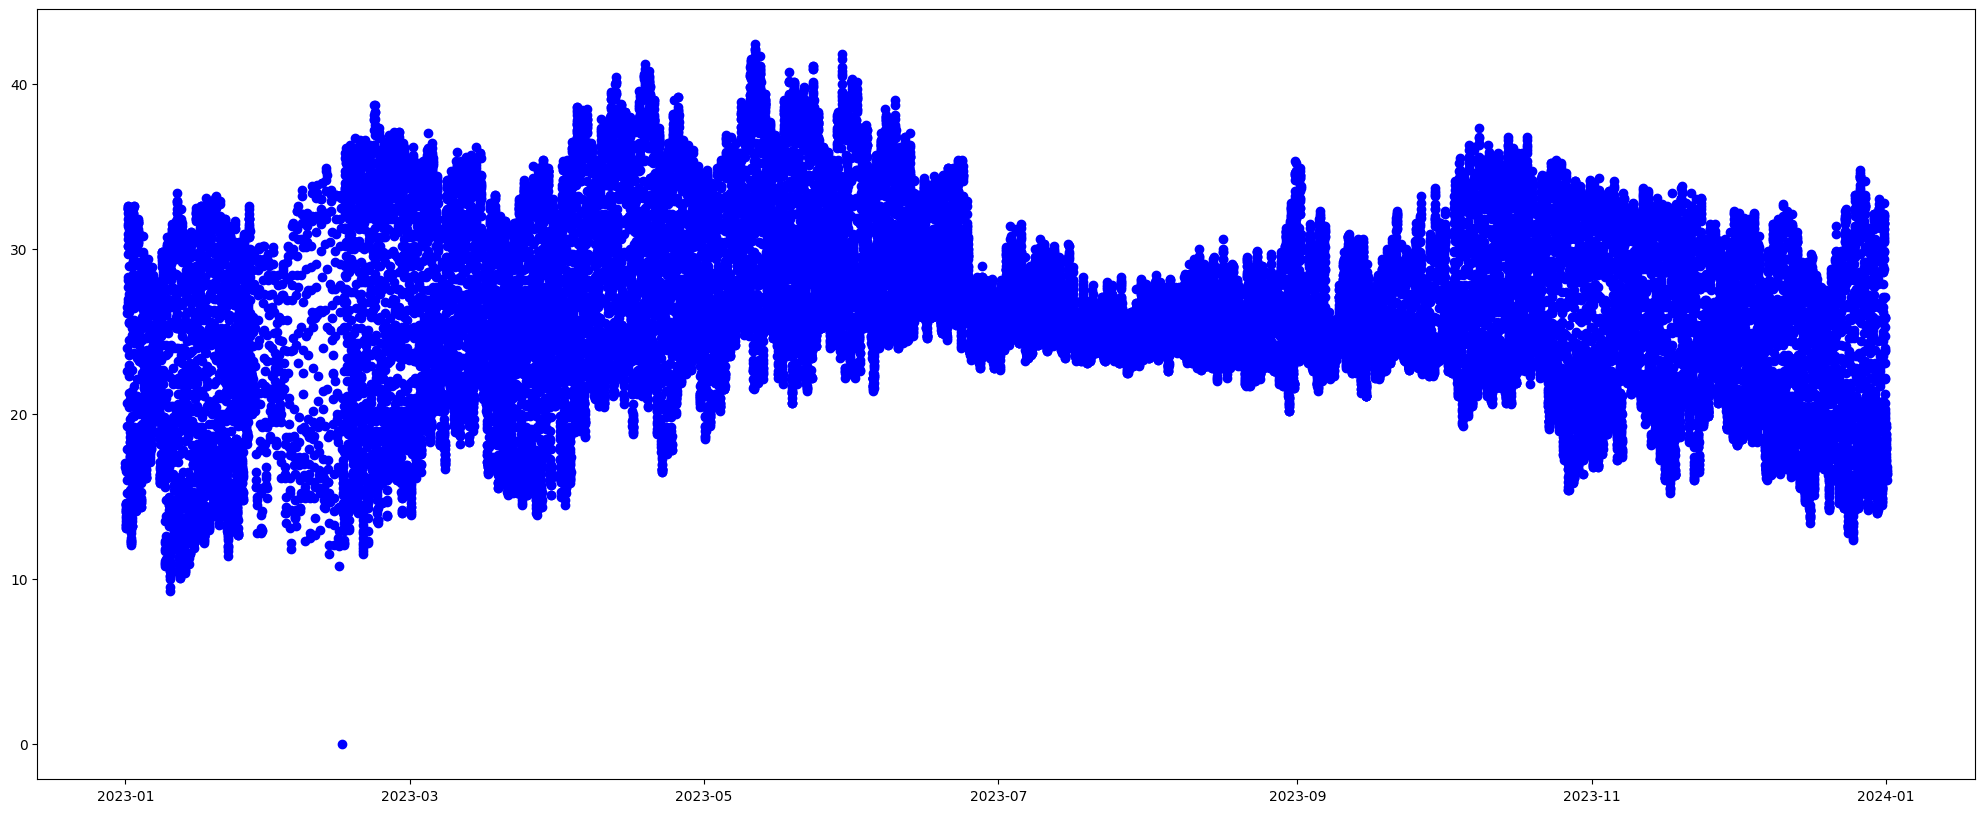

In [3]:
plt.figure(figsize=(25, 10))
plt.scatter(weather_data['Date'], weather_data['Temp'], label= 'Temp', color='blue')

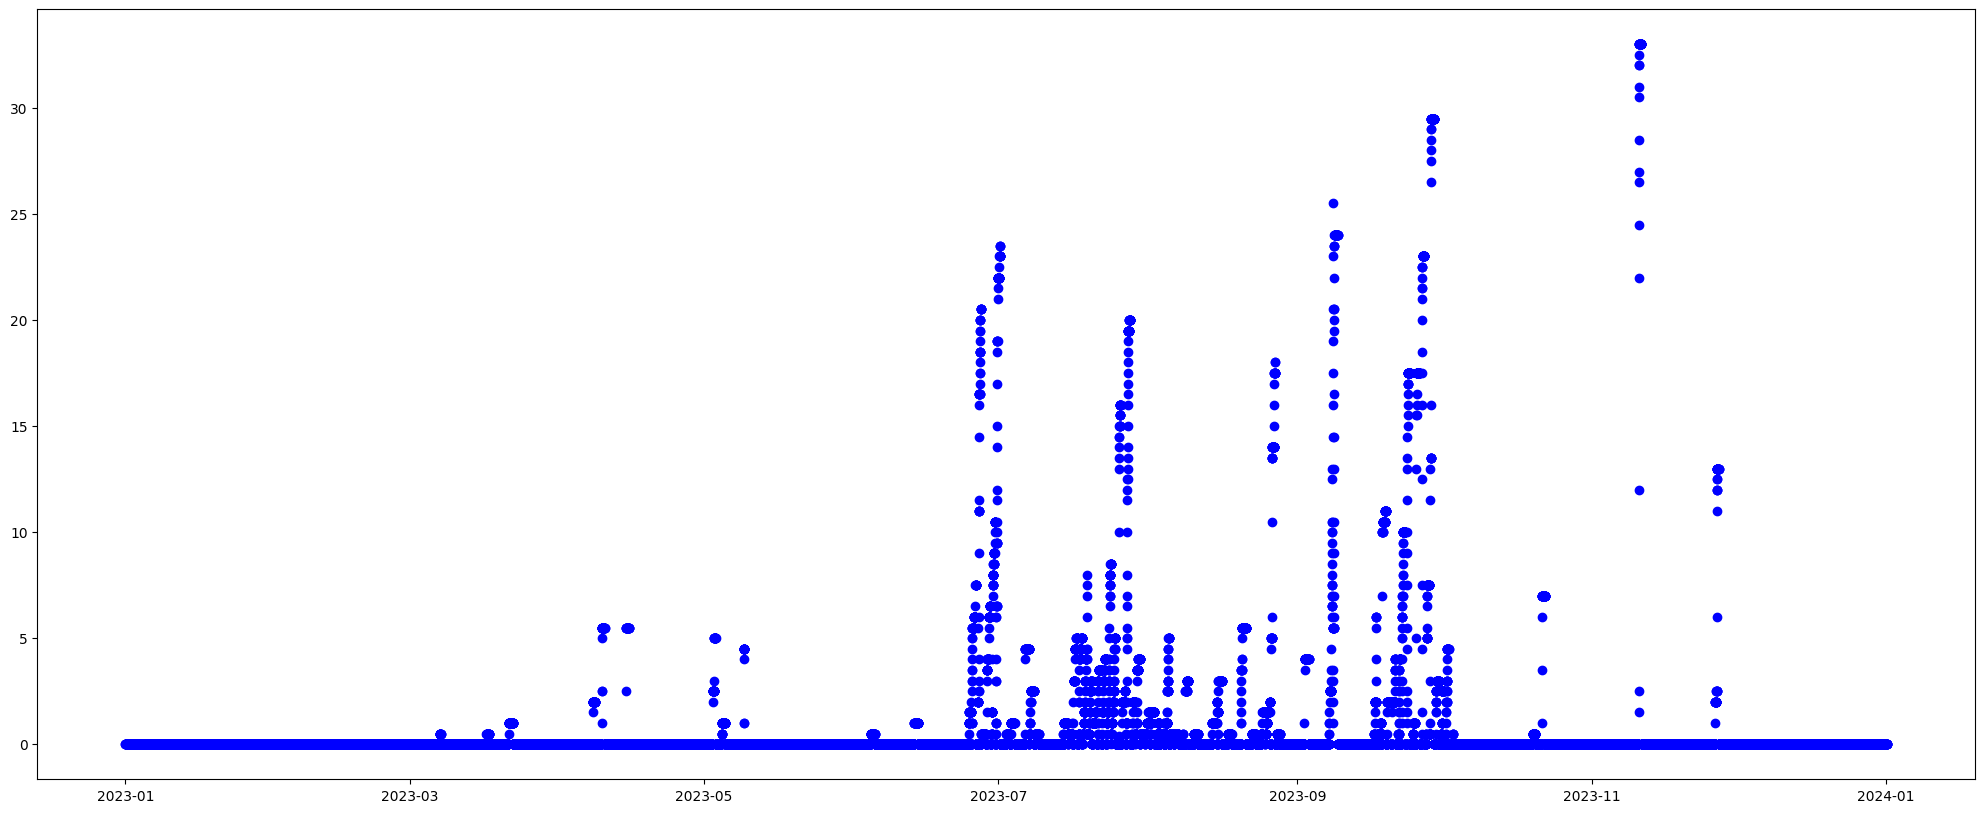

In [5]:
plt.figure(figsize=(25, 10))
plt.scatter(weather_data['Date'], weather_data['Rain(mm)'], label= 'Rain', color='blue')

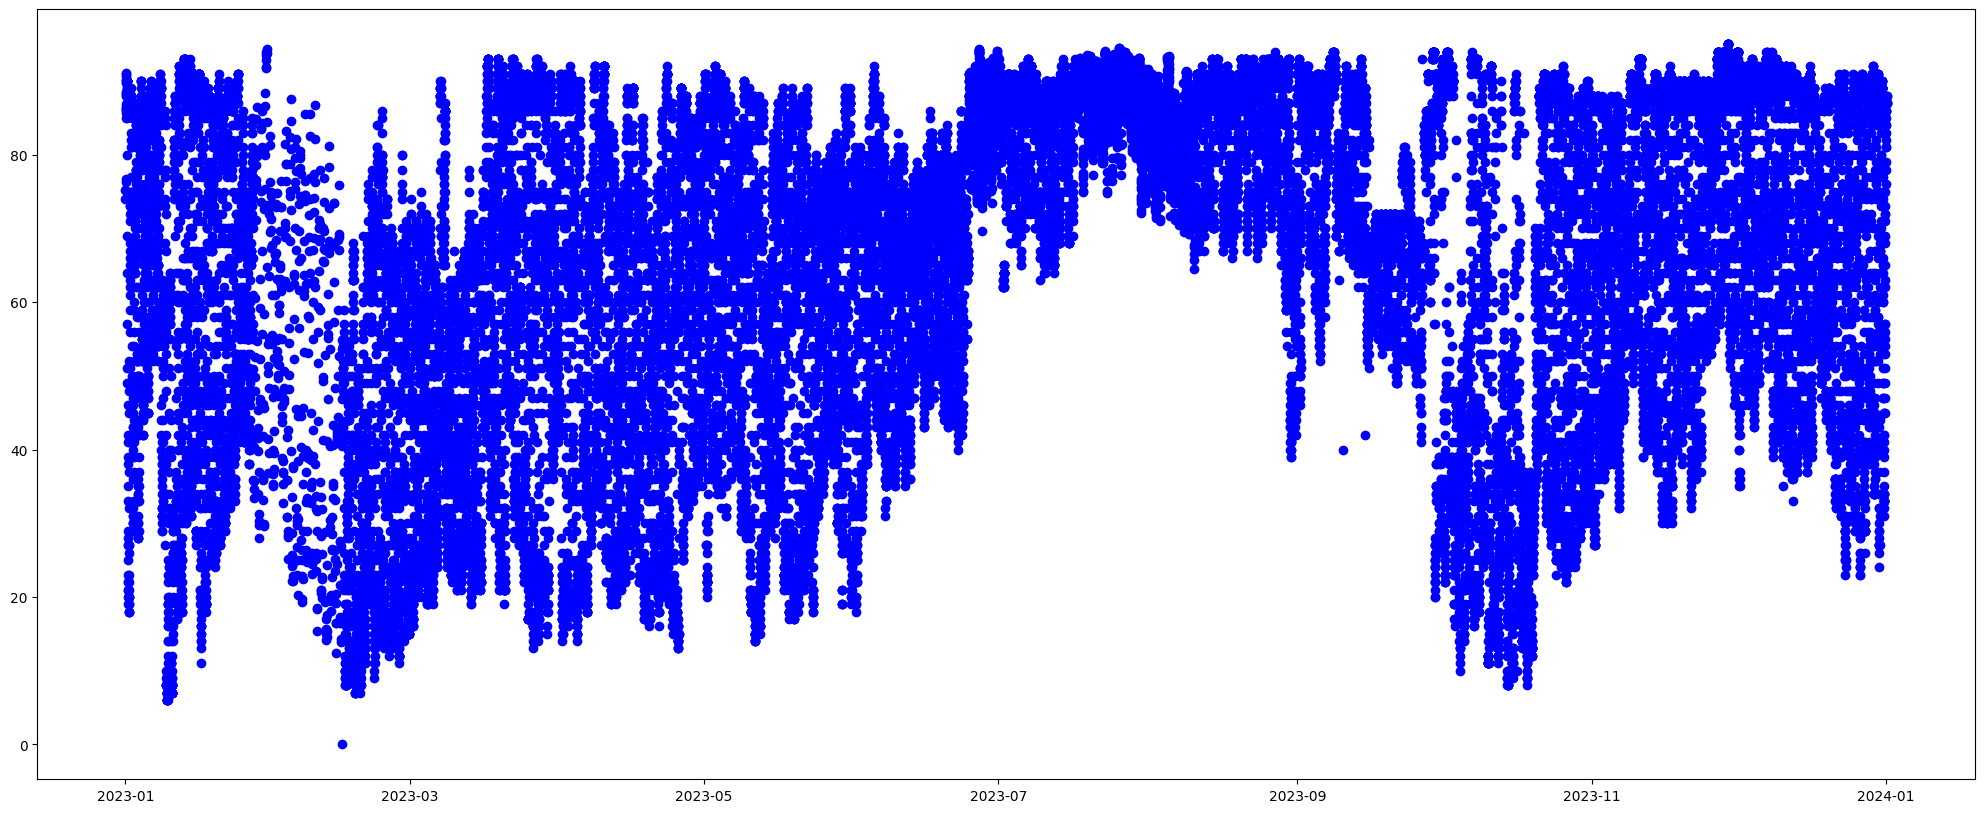

In [6]:
plt.figure(figsize=(25, 10))
plt.scatter(weather_data['Date'], weather_data['RH(%)'], label= 'Humidity', color='blue')

## Thrips

In [2]:
kharif = pd.read_csv('C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Thrips Data\Clean_Data\Kharif_Data.csv')
kharif = kharif[sorted(kharif.columns)]
kharif['Date'] = pd.to_datetime(kharif['Date'], format="%d.%m.%Y")
rabi = pd.read_csv('C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Thrips Data\Clean_Data\Rabi_Data.csv')
rabi = rabi[sorted(rabi.columns)]
rabi['Date'] = pd.to_datetime(rabi['Date'], format='%m/%d/%Y')

C:\Users\manas\AppData\Local\Temp\ipykernel_21456\4183624476.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(kharif['Date'], kharif[col], label=col, c = rgb_values[kharif_cols.index(col)])


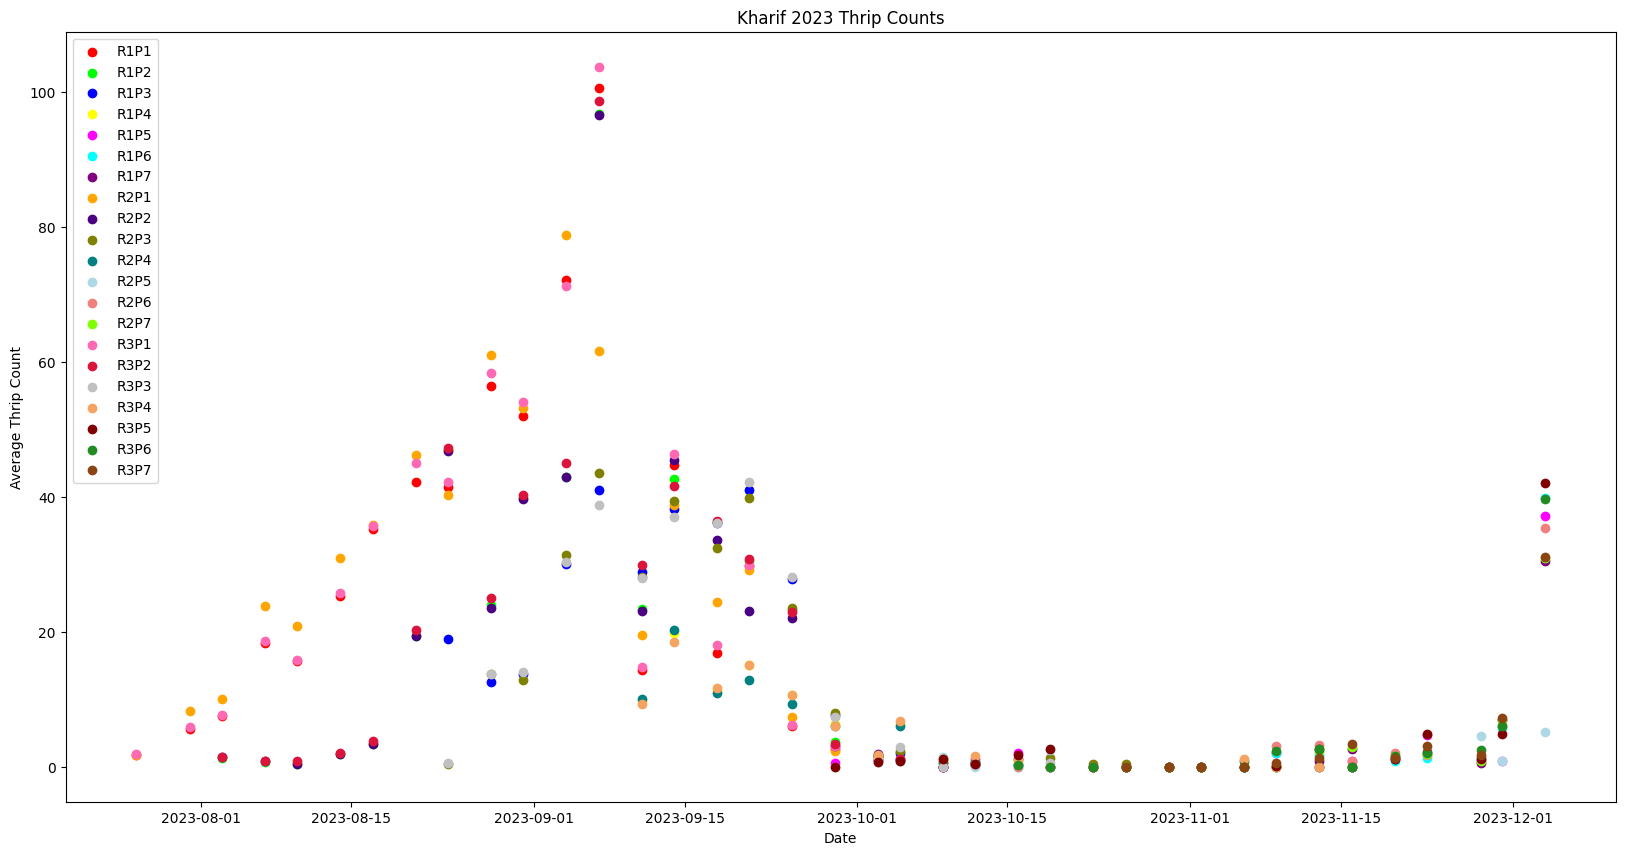

In [3]:
kharif_cols = []
for col in kharif.columns:
    if col != 'Date':
        kharif_cols.append(col)

fig = plt.figure(figsize=(20 ,10))
ax1 = fig.add_subplot(111)

for col in kharif_cols:
    ax1.scatter(kharif['Date'], kharif[col], label=col, c = rgb_values[kharif_cols.index(col)])
plt.legend(loc=2)
plt.ylabel('Average Thrip Count')
plt.xlabel('Date')
plt.title('Kharif 2023 Thrip Counts')
plt.show()

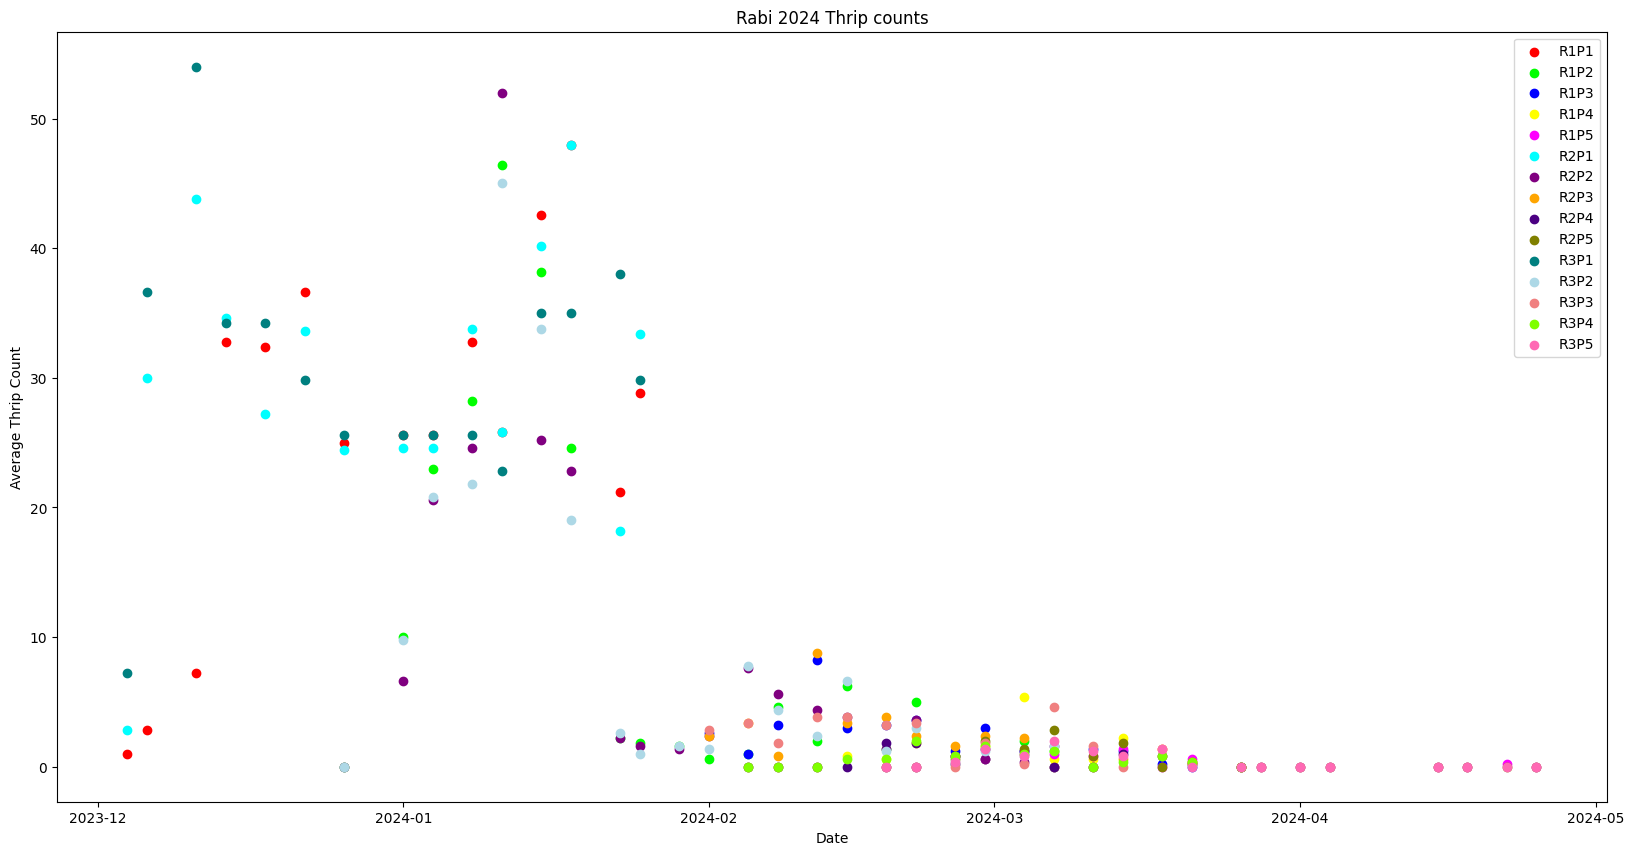

In [4]:
rabi_cols = []
for col in rabi.columns:
    if col != 'Date':
        rabi_cols.append(col)

fig = plt.figure(figsize=(20 ,10))
ax1 = fig.add_subplot(111)

for col in rabi_cols:
    ax1.scatter(rabi['Date'], rabi[col], label=col, color = rgb_values[rabi_cols.index(col)])
plt.legend(loc=0)
plt.ylabel('Average Thrip Count')
plt.xlabel('Date')
plt.title("Rabi 2024 Thrip counts")
plt.show()

# Data Loader

In [2]:
class DataLoader: 
    def __init__(self, dop = KHARIF_DOP, weather = WEATHER_PATH, thrips = KHARIF_PATH, format = "%d.%m.%Y"):
        if isinstance(weather, str):
            if weather.endswith('csv'):
                self.weather_data = pd.read_csv(weather)
            elif weather.endswith('xlsx'):
                self.weather_data = pd.read_excel(weather)
        elif isinstance(weather, pd.DataFrame):
            self.weather_data = weather
        else:
            raise ValueError("Input should be file path (str) or Pandas DataFrame")
        if 'Date(IST)' in self.weather_data.columns:
            self.weather_data.rename(columns={'Date(IST)': 'Date'}, inplace=True)
        self.weather_data['Date'] = pd.to_datetime(self.weather_data['Date'], format = '%Y-%m-%d %H:%M:%S')
        self.weather_data['Rain(mm)'] = self.weather_data['Rain(mm)'].fillna(0)
        
        if thrips == None:
            print('Thrips data not provided. Only weather data can be generated.')
        else:
            if isinstance(thrips, str):
                self.thrips_data = pd.read_csv(thrips)
            elif isinstance(thrips, pd.DataFrame):
                self.thrips_data = thrips
            else:
                raise ValueError("Input should be file path (str) or Pandas DataFrame")
            self.thrips_data['Date'] = pd.to_datetime(self.thrips_data['Date'], format=format)
            self.thrips_data.drop(self.thrips_data.filter(regex = '6$').columns, axis = 1, inplace = True)
            self.thrips_data.drop(self.thrips_data.filter(regex = '7$').columns, axis = 1, inplace = True)
            
        self.dop = dop                                                                 # date of plantation in DD-MM-YYYY indexed by trial number. 
        for i in self.dop.keys():
            self.dop[i] = pd.to_datetime(self.dop[i], format = "%d-%m-%Y")
        self.dataset = None

    def categorize_percentile(self, series, labels=['L1', 'L2', 'L3', 'L4', 'L5'], percentiles = [0, 20, 40, 60, 80, 100]):
        if labels is None:
            labels = []
            for i in range(len(percentiles) - 1):
                lv = round(series.quantile(percentiles[i]/100.0), 2)
                hv = round(series.quantile(percentiles[i+1]/100.0), 2)
                labels.append(f'{lv}-{hv}')
        bins = np.percentile(series, percentiles)
        return pd.cut(series, bins=bins, labels=labels, include_lowest=True)

    def categorize_knn(self, series, n_clusters=5, labels=None):
        """
        Categorize a pandas Series using KMeans clustering.
        
        Parameters:
        - series (pd.Series): The data to categorize.
        - n_clusters (int): Number of clusters to form.
        - labels (list): Labels for the categories. Defaults to cluster numbers.
        
        Returns:
        - pd.Series: Categorized data with specified labels or cluster indices.
        """
        # Reshape data for clustering
        series_reshaped = series.values.reshape(-1, 1)
        
        # Perform KMeans clustering
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
        cluster_labels = kmeans.fit_predict(series_reshaped)
        
        # Create a DataFrame to group values by clusters
        df = pd.DataFrame({'value': series, 'cluster': cluster_labels})
        
        # Calculate min and max for each cluster
        cluster_ranges = (
            df.groupby('cluster')['value']
            .agg(['min', 'max'])
            .sort_index()
        )
        
        # Create cluster labels based on min and max ranges
        labels = [
            f"{round(row['min'], 2)}-{round(row['max'], 2)}"
            for _, row in cluster_ranges.iterrows()
        ]
        
        # Map cluster indices to range labels
        label_mapping = {i: labels[i] for i in range(n_clusters)}
        categorized_series = pd.Series(cluster_labels, index=series.index).map(label_mapping)
        
        return categorized_series
    def get_data(self, date, lag = 0):                          # Returns subset of data with specified date and lag (one week data)
        start_date = date - datetime.timedelta(days = (lag+1)*7)
        end_date = start_date + datetime.timedelta(days = 7)
        sub_data = self.weather_data[(self.weather_data['Date'].dt.date>=start_date) & (self.weather_data['Date'].dt.date<=end_date)]
        return sub_data

    def get_aggregate_data(self, sub_data, lag = 0):            # Returns aggregate data for given subset of data.
        tmin = min(sub_data['Temp'])
        tmax = max(sub_data['Temp'])
        tmean = np.mean(sub_data['Temp']) if len(sub_data)>0 else 0
        
        morning_data = sub_data.loc[(sub_data['Date'].dt.time >= datetime.time(6, 0)) & (sub_data['Date'].dt.time<=datetime.time(9,0))]
        evening_data = sub_data.loc[(sub_data['Date'].dt.time >= datetime.time(17, 0)) & (sub_data['Date'].dt.time<=datetime.time(20,0))]

        rh1 = morning_data['RH(%)'].mean() if len(morning_data)>0 else np.nan
        rh2 = evening_data['RH(%)'].mean() if len(evening_data)>0 else np.nan

        data = {
            'tmin'+str(lag): tmin,
            'tmax'+str(lag): tmax, 
            # 'rain'+str(lag): rain,
            'tmean'+str(lag): tmean,
            'rh1'+str(lag): rh1, 
            'rh2'+str(lag): rh2
        }
        if lag == 0:
            data['rain0'], data['rain1'], data['rain2'] = self.get_rain_data(sub_data)
        return data
    
    def get_rain_data(self, sub_data):
        today = sub_data['Date'].dt.date.max()
        if pd.isnull(today):
            return 0, 0, 0  # If no data, return zeros

        rain_today = sub_data.loc[sub_data['Date'].dt.date == today, 'Rain(mm)'].max()
        rain_today = rain_today if rain_today is not None else 0
        yesterday = today - datetime.timedelta(days=1)
        rain_yesterday = sub_data.loc[sub_data['Date'].dt.date == yesterday, 'Rain(mm)'].max()
        rain_yesterday = rain_yesterday if rain_yesterday is not None else 0
        day_before_yesterday = today - datetime.timedelta(days=2)
        rain_day_before_yesterday = sub_data.loc[sub_data['Date'].dt.date == day_before_yesterday, 'Rain(mm)'].max()
        rain_day_before_yesterday = rain_day_before_yesterday if rain_day_before_yesterday is not None else 0
        return rain_today, rain_yesterday, rain_day_before_yesterday


    def get_lag_weather(self, dates = None):                                # Returns aggregate lagged data (like rain0: rainfall in current week and soan papdi)
        df = []
        if dates is None:
            dates = self.thrips_data['Date']
        for date in dates.dt.date:
            data = {}
            for lag in range(3):
                sub_data = self.get_data(date, lag)
                if len(sub_data) == 0:
                    raise ValueError(f"No weather data found on {date}")
                data.update(self.get_aggregate_data(sub_data, lag))
            data.update({'Date': date})
            df.append(data)
        df = pd.DataFrame(df)
        df = df[sorted(df.columns)]
        return df
    
    def get_correlations(self, trials = None, start_date = True):       # Returns correlation of thrips incidence with weather parameters and age.
        ret = {}
        data = self.get_lag_weather()
        var = list(data.columns)
        var.remove('Date')
        if trials is None:
            trials = list(self.thrips_data.columns)
            trials.remove('Date')
        age_data = self.get_age_data(start=start_date)
        for trial in trials:
            age_col = 'age_P'+trial[-1]
            temp = pd.concat([data, self.thrips_data[trial], age_data], axis = 1)[var+[trial, age_col]].dropna()
            temp.rename(columns={age_col: 'age'}, inplace=True)
            result = dict(temp.corr()[trial])
            result.pop(trial)
            ret[trial] = result
        return ret    

    def get_dataset(self, trials, start = False, remove_dates = True, cache = True):                              # Returns dataset with weather parameters and thrips data of specified trial.
        if cache:
            return self.dataset
        df = []
        for trial in trials:
            X = self.get_lag_weather()
            if start:
                X['Age'] = X['Date'].apply(lambda x: (pd.Timestamp(x) - self.dop['1']).days)
            else:
                X['Age'] = X['Date'].apply(lambda x: (pd.Timestamp(x) - self.dop[trial[-1]]).days)
            if remove_dates:
                X.drop(labels = 'Date', axis = 1, inplace = True)
            y = self.thrips_data[trial]
            res = pd.concat([X, y], axis=1).dropna()
            res.rename(columns={trial: 'thrip_count'}, inplace=True)
            df.append(res)
        self.dataset = pd.concat(df, axis = 0).reset_index(drop = True)
        return self.dataset
    
    def get_pop_change(self, verbose = False, name_change = True):                                               # Get average Population Delta 
        dfs = []
        for trial in self.thrips_data.filter(regex = "^R").columns:
            subset = self.thrips_data[['Date', trial]].dropna().reset_index(drop = True)
            dlt = []
            for i in range(len(subset)):
                if i == 0:
                    days = (subset.iloc[i]['Date'] - self.dop[trial[-1]]).days
                    dlt.append(subset.iloc[i][trial]/days)
                else:
                    days = (subset.iloc[i]['Date'] - subset.iloc[i-1]['Date']).days
                    diff = subset.iloc[i][trial] - subset.iloc[i-1][trial]
                    dlt.append(diff/days)
            subset['pop_change_'+trial] = dlt
            subset.drop(columns = trial, inplace = True)
            dfs.append(subset)
        alt = self.thrips_data.copy(deep = True)
        for sub in dfs:
            alt = alt.join(sub.set_index('Date'), on = 'Date')
        if verbose:
            return alt
        alt.drop(self.thrips_data.filter(regex='^R').columns, axis = 1, inplace=True)
        if name_change:
            for trial in self.thrips_data.filter(regex="^R").columns:
                alt.rename({'pop_change_'+trial: trial}, inplace=True, axis=1)
        return alt
    def get_age_data(self, verbose = False, start = True):                  # Function to get age of plant (start = True gives age starting from date of first trial)
        dfs = []
        for trial in self.thrips_data.filter(regex='^R1').columns:
            subset = self.thrips_data[['Date', trial]].dropna().reset_index(drop = True)
            dlt = []
            for i in range(len(subset)):
                if start:
                    days = (subset.iloc[i]['Date'] - self.dop['1']).days
                else:
                    days = (subset.iloc[i]['Date'] - self.dop[trial[-1]]).days
                dlt.append(days)
            subset['age_'+trial[-2:]] = dlt
            subset.drop(columns = trial, inplace = True)
            dfs.append(subset)
        alt = self.thrips_data.copy(deep = True)
        for sub in dfs:
            alt = alt.join(sub.set_index('Date'), on='Date')
        if not verbose:
            return alt.filter(regex='^age')
        else:
            return alt
    def get_thrips_distribution(self, season, dataset = None, save_plot = False):
        if dataset == None:
            dataset = self.dataset
        df = pd.DataFrame()
        for col in dataset.drop(['thrip_count', 'Age'], axis = 1).columns:
            df[col] = self.categorize_knn(dataset[col], labels=None, n_clusters=5)
        df['Age'] = dataset['Age']
        df['thrip_count'] = dataset['thrip_count']
        if save_plot:
            for col in dataset.drop(['thrip_count', 'Age'], axis=1).columns:
                plt.figure()
                sns.boxplot(data=df, x=f'{col}', y='thrip_count')
                plt.savefig(f"Presentation/Critical_Values_KNN/{season}/Thrips/{col}_thrips.png", dpi=300, bbox_inches='tight')
                plt.close()
        return df


In [3]:
kharif_data = DataLoader(thrips='C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Thrips Data\Clean_Data\Kharif_Data.csv')
kharif_dataset = kharif_data.get_dataset(kharif_data.thrips_data.filter(regex='^R').columns, start = False, cache=False)
kharif_dataset

,rain0,rain1,rain2,rh10,rh11,rh12,rh20,rh21,rh22,tmax0,tmax1,tmax2,tmean0,tmean1,tmean2,tmin0,tmin1,tmin2,Age,thrip_count
0,16.0,5.0,8.5,89.838000,88.936538,87.669903,87.395146,85.000971,80.592233,28.3,30.3,31.5,24.646986,25.285792,26.084853,23.1,23.1,23.2,15,1.8
1,1.0,4.0,3.5,88.497059,89.465686,87.701923,87.494231,87.824272,80.980392,28.3,28.3,30.3,24.554509,24.651771,25.798919,22.5,23.1,23.2,20,5.6
2,1.0,1.5,1.5,86.542157,89.981000,89.249515,85.582353,87.855340,85.831068,28.4,28.3,30.3,24.756680,24.573670,25.115510,22.5,22.5,23.1,23,7.5
3,0.5,0.5,5.0,84.998039,88.497059,89.465686,82.740816,87.494231,87.824272,28.4,28.3,28.3,25.072653,24.554509,24.651771,22.6,22.5,23.1,27,18.3
4,0.5,3.0,2.5,85.134615,86.542157,89.981000,80.557576,85.582353,87.855340,29.4,28.4,28.3,25.146703,24.756680,24.573670,22.6,22.5,22.5,30,15.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,0.0,0.0,0.0,83.901961,81.588235,77.801980,58.420000,63.644231,49.404040,33.8,33.7,34.3,24.305976,25.553623,25.056242,15.2,17.2,16.4,70,1.2
293,0.0,0.0,0.0,84.145631,84.970297,78.247525,55.730000,62.951923,56.480392,33.8,33.7,34.3,24.191877,25.068956,25.490040,15.2,16.0,16.8,73,4.9
294,0.0,13.0,12.0,87.504854,84.362745,82.284314,65.524752,56.280000,65.211538,33.4,33.8,33.7,24.345491,24.263214,25.578026,16.0,15.2,17.4,78,1.2
295,0.0,0.0,0.0,90.106796,84.145631,84.970297,71.207921,55.730000,62.951923,33.1,33.8,33.7,24.071713,24.191877,25.068956,16.5,15.2,16.0,80,4.9


In [4]:
rabi_data = DataLoader(thrips='C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Thrips Data\Clean_Data\Rabi_Data.csv', format='%m/%d/%Y')
rabi_dataset = rabi_data.get_dataset(rabi_data.thrips_data.filter(regex='^R').columns, start = False, cache=False)
rabi_dataset

,rain0,rain1,rain2,rh10,rh11,rh12,rh20,rh21,rh22,tmax0,tmax1,tmax2,tmean0,tmean1,tmean2,tmin0,tmin1,tmin2,Age,thrip_count
0,0.0,0.0,0.0,92.362745,85.894231,83.901961,67.009901,63.980198,58.420000,32.3,33.4,33.8,24.094063,24.524170,24.305976,18.1,16.0,15.2,146,1.0
1,0.0,0.0,0.0,91.310680,89.135922,84.303922,65.774510,68.277228,55.110000,32.3,33.1,33.8,23.809486,24.124037,24.194555,18.1,16.0,15.2,148,2.8
2,0.0,0.0,0.0,90.277228,92.362745,85.894231,62.230000,67.009901,63.980198,32.7,32.3,33.4,23.193360,24.094063,24.524170,16.0,18.1,16.0,153,7.2
3,0.0,0.0,0.0,89.330000,91.029126,90.106796,58.210000,66.117647,71.207921,32.7,32.3,33.1,22.655451,23.610935,24.071713,15.5,16.0,16.5,156,32.8
4,0.0,0.0,0.0,85.818182,90.277228,92.362745,56.872549,62.230000,67.009901,32.3,32.7,32.3,22.047376,23.193360,24.094063,13.4,16.0,18.1,160,32.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,0.0,0.2,0.0,66.362500,66.348958,65.725000,32.730208,26.492708,26.328125,39.6,38.9,37.0,29.432682,26.282682,25.419141,18.3,12.9,12.7,203,0.0
245,0.1,0.0,0.0,64.953125,67.548958,65.109375,31.587500,31.800000,24.080208,38.9,39.6,36.3,29.249349,27.899219,25.025391,17.2,13.9,12.7,206,0.0
246,4.5,0.1,0.0,61.471875,61.644792,66.362500,28.847917,25.953125,32.730208,40.2,38.9,39.6,28.740885,28.668620,29.432682,16.1,16.1,18.3,217,0.0
247,0.6,0.4,4.5,65.755952,60.352083,64.953125,31.631944,26.337500,31.587500,41.8,38.8,38.9,29.697352,28.683854,29.249349,16.1,16.1,17.2,220,0.0


# Weather Visualization

In [ ]:
min_date = kharif_data.thrips_data['Date'].min()
max_date = kharif_data.thrips_data['Date'].max()
weather_sub = kharif_data.weather_data[(kharif_data.weather_data['Date']<=max_date) & (kharif_data.weather_data['Date']>=min_date)]
rainfall = weather_sub['Rain(mm)']
humidity = weather_sub['RH(%)']
temperature = weather_sub['Temp']
dates = weather_sub['Date']
thrip_dates = []
thrip_count = []
for date in kharif_data.thrips_data['Date']:
    sub_data = kharif_data.thrips_data[kharif_data.thrips_data['Date'] == date]
    sub_data = sub_data.dropna(axis = 1)
    sub_data.reset_index(inplace=True)
    if len(sub_data)>0:
        for col in sub_data.drop(['Date', 'index'], axis = 1).columns:    
            try:
                thrip_count.append(sub_data[col][0])
                thrip_dates.append(date)
            except Exception:
                print(date)

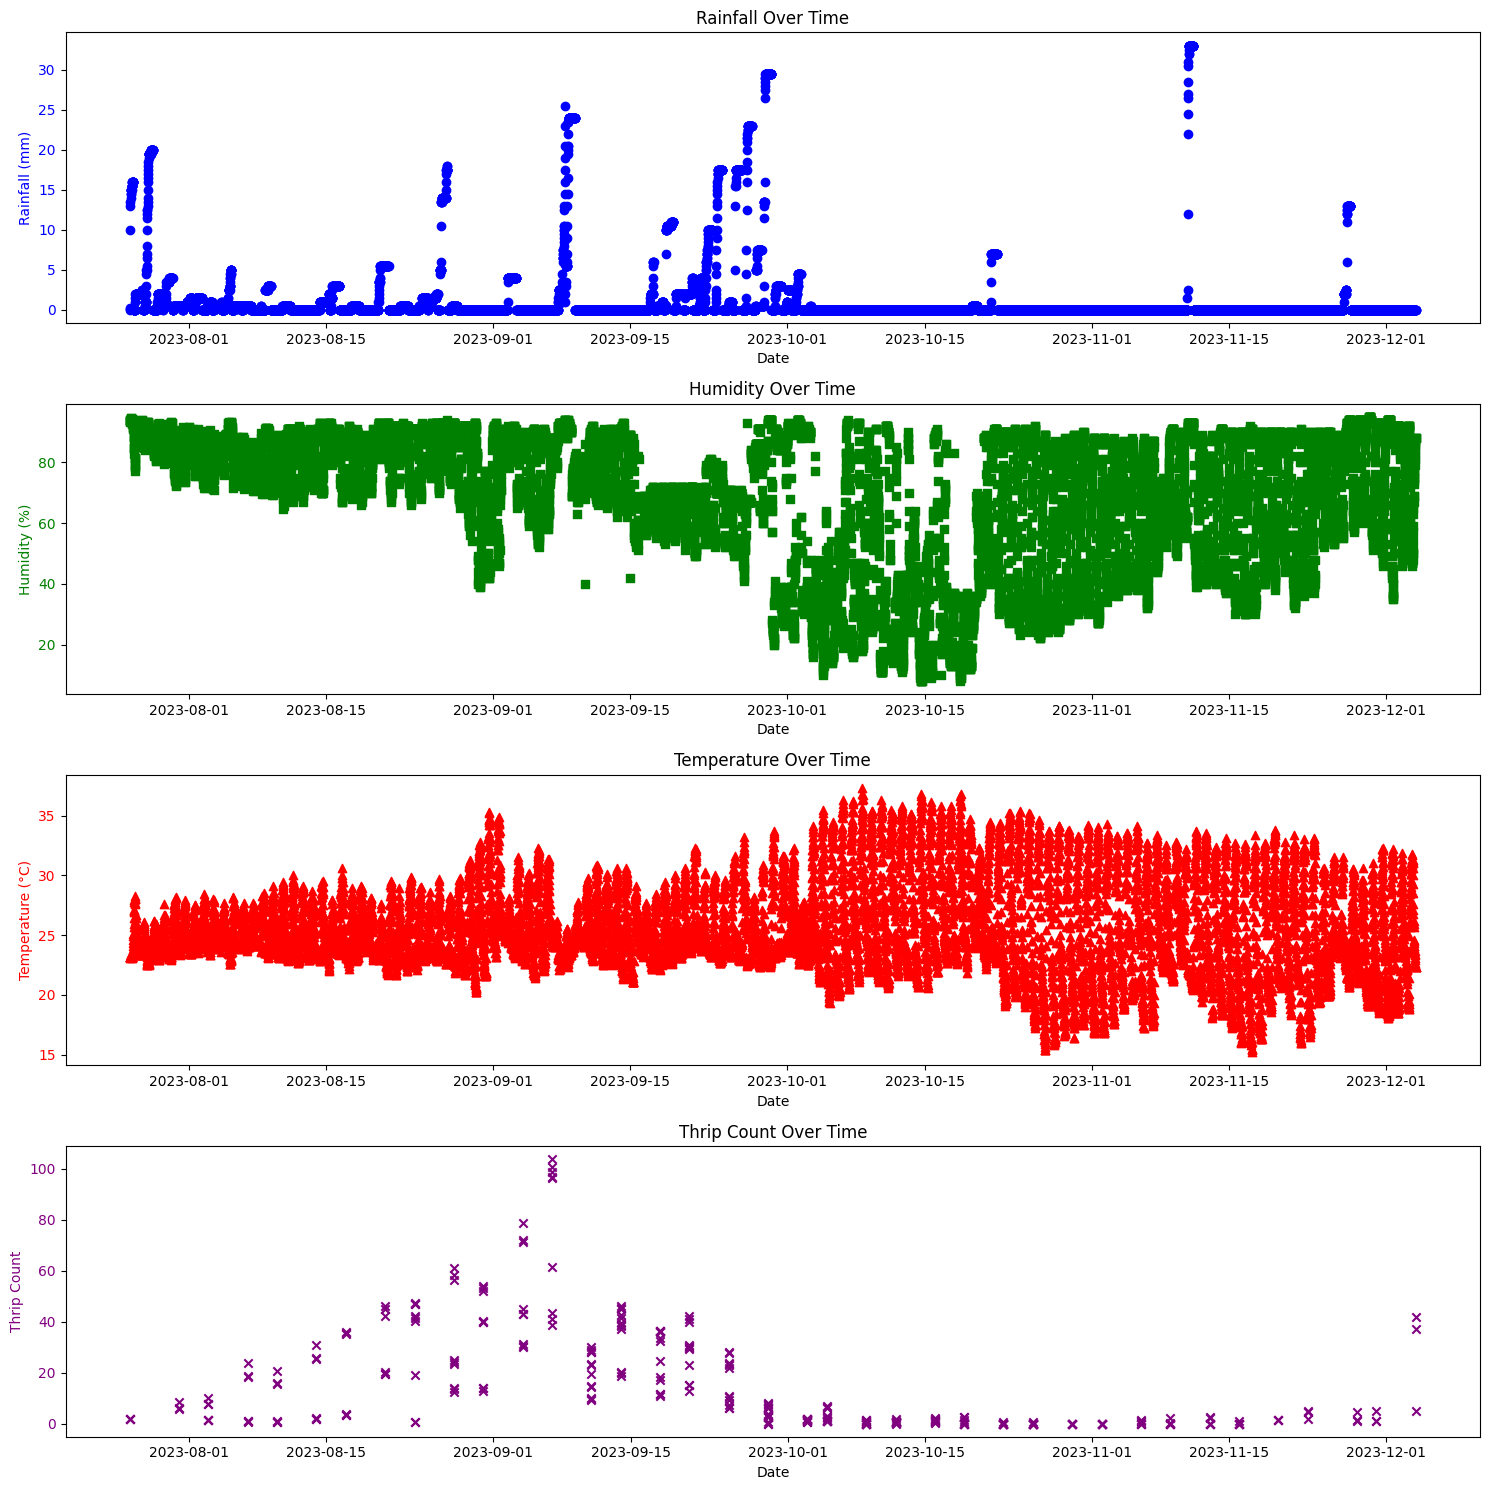

In [66]:
# Create subplots with separate x-axes
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 15), sharey=False)

# Plot each variable on its own subplot
ax1.scatter(dates, rainfall, color='blue', marker='o')
ax1.set_ylabel('Rainfall (mm)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xlabel('Date')
ax1.set_title('Rainfall Over Time')

ax2.scatter(dates, humidity, color='green', marker='s')
ax2.set_ylabel('Humidity (%)', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_xlabel('Date')
ax2.set_title('Humidity Over Time')

ax3.scatter(dates, temperature, color='red', marker='^')
ax3.set_ylabel('Temperature (°C)', color='red')
ax3.tick_params(axis='y', labelcolor='red')
ax3.set_xlabel('Date')
ax3.set_title('Temperature Over Time')

ax4.scatter(thrip_dates, thrip_count, color='purple', marker='x')
ax4.set_ylabel('Thrip Count', color='purple')
ax4.tick_params(axis='y', labelcolor='purple')
ax4.set_xlabel('Date')
ax4.set_title('Thrip Count Over Time')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [27]:
from datetime import timedelta
min_date = rabi_data.thrips_data['Date'].min()
max_date = rabi_data.thrips_data['Date'].min() + timedelta(days = 1)
weather_sub = rabi_data.weather_data[(rabi_data.weather_data['Date']<=max_date) & (rabi_data.weather_data['Date']>=min_date)]
rainfall = weather_sub['Rain(mm)']
humidity = weather_sub['RH(%)']
temperature = weather_sub['Temp']
dates = weather_sub['Date']
thrip_dates = []
thrip_count = []
for date in rabi_data.thrips_data['Date']:
    sub_data = rabi_data.thrips_data[rabi_data.thrips_data['Date'] == date]
    sub_data = sub_data.dropna(axis = 1)
    sub_data.reset_index(inplace=True)
    if len(sub_data)>0:
        for col in sub_data.drop(['Date', 'index'], axis = 1).columns:    
            try:
                thrip_count.append(sub_data[col][0])
                thrip_dates.append(date)
            except Exception:
                print(date)

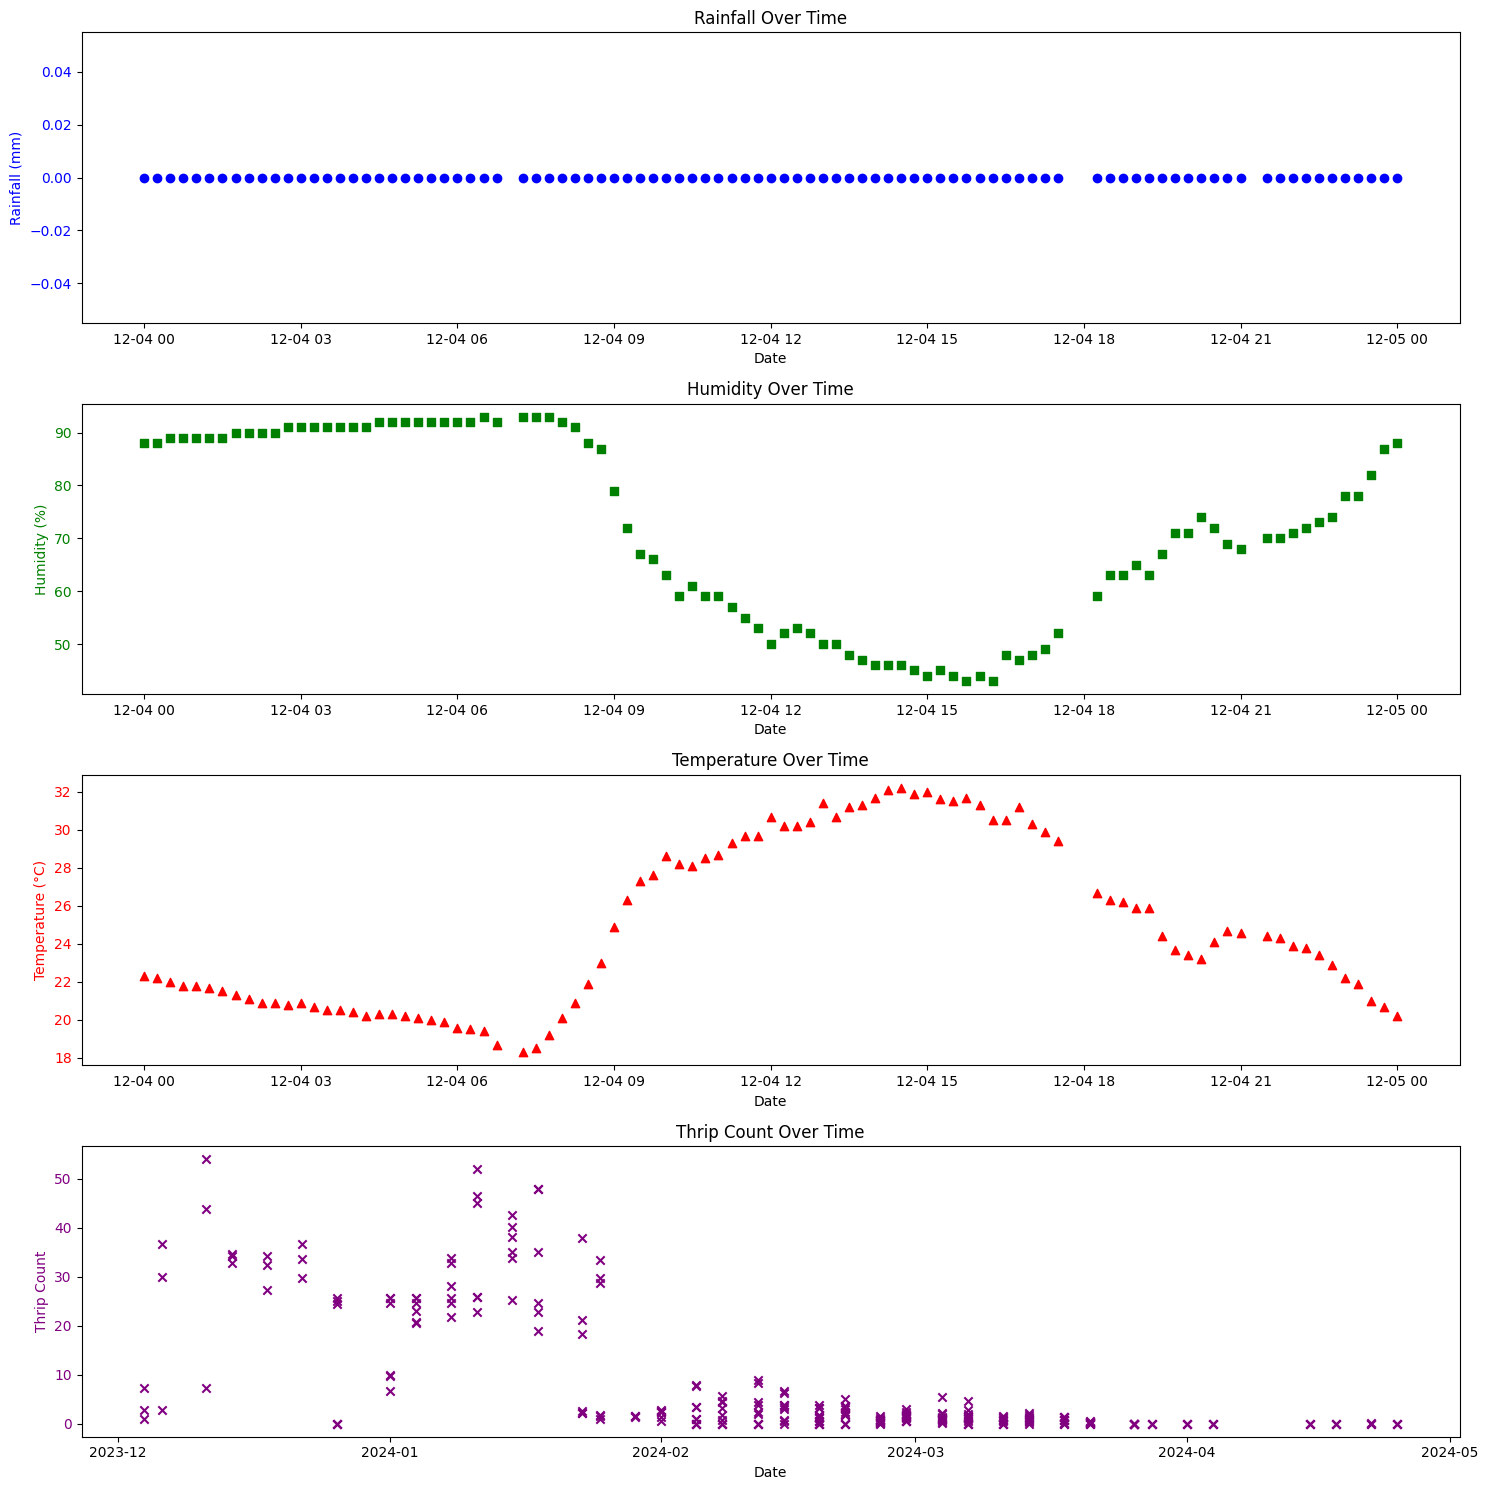

In [28]:
# Create subplots with separate x-axes
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 15), sharey=False)

# Plot each variable on its own subplot
ax1.scatter(dates, rainfall, color='blue', marker='o')
ax1.set_ylabel('Rainfall (mm)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xlabel('Date')
ax1.set_title('Rainfall Over Time')

ax2.scatter(dates, humidity, color='green', marker='s')
ax2.set_ylabel('Humidity (%)', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_xlabel('Date')
ax2.set_title('Humidity Over Time')

ax3.scatter(dates, temperature, color='red', marker='^')
ax3.set_ylabel('Temperature (°C)', color='red')
ax3.tick_params(axis='y', labelcolor='red')
ax3.set_xlabel('Date')
ax3.set_title('Temperature Over Time')

ax4.scatter(thrip_dates, thrip_count, color='purple', marker='x')
ax4.set_ylabel('Thrip Count', color='purple')
ax4.tick_params(axis='y', labelcolor='purple')
ax4.set_xlabel('Date')
ax4.set_title('Thrip Count Over Time')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


# Data Testing

In [28]:
# Try Granger Causality Test

import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests


# Define a function to test Granger causality on specific columns
def granger_causality_test(df, target_var, test_vars, max_lag=2):
    """
    Performs Granger causality test for specified target variable against each test variable.
    
    Parameters:
    - df: DataFrame containing the dataset.
    - target_var: The column name of the dependent variable (thrip_count).
    - test_vars: List of column names of the independent variables to test.
    - max_lag: Maximum lag to test for Granger causality (default is 2 for weekly lagged data).
    """
    for var in test_vars:
        print(f'\nGranger Causality Test for {var} -> {target_var}')
        grangercausalitytests(df[[target_var, var]], max_lag, verbose=True)

# Define the target and test variables
target_var = 'thrip_count'
test_vars = ['rain0', 'rain1', 'rain2', 'rh10', 'rh11', 'rh12', 'rh20', 'rh21', 
             'rh22', 'tmax0', 'tmax1', 'tmax2', 'tmean0', 'tmean1', 'tmean2',
             'tmin0', 'tmin1', 'tmin2', 'Age']


In [29]:
granger_causality_test(kharif_dataset, target_var, test_vars, max_lag=1)



Granger Causality Test for rain0 -> thrip_count

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=6.4338  , p=0.0117  , df_denom=293, df_num=1
ssr based chi2 test:   chi2=6.4996  , p=0.0108  , df=1
likelihood ratio test: chi2=6.4293  , p=0.0112  , df=1
parameter F test:         F=6.4338  , p=0.0117  , df_denom=293, df_num=1

Granger Causality Test for rain1 -> thrip_count

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.7902  , p=0.3748  , df_denom=293, df_num=1
ssr based chi2 test:   chi2=0.7983  , p=0.3716  , df=1
likelihood ratio test: chi2=0.7972  , p=0.3719  , df=1
parameter F test:         F=0.7902  , p=0.3748  , df_denom=293, df_num=1

Granger Causality Test for rain2 -> thrip_count

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1591  , p=0.6902  , df_denom=293, df_num=1
ssr based chi2 test:   chi2=0.1608  , p=0.6884  , df=1
likelihood ratio test: chi2=0.1607  , p=0.6885  , df=1
parameter F test:   

In [30]:
granger_causality_test(rabi_dataset, target_var, test_vars, max_lag=1)



Granger Causality Test for rain0 -> thrip_count

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1902  , p=0.6631  , df_denom=245, df_num=1
ssr based chi2 test:   chi2=0.1925  , p=0.6608  , df=1
likelihood ratio test: chi2=0.1924  , p=0.6609  , df=1
parameter F test:         F=0.1902  , p=0.6631  , df_denom=245, df_num=1

Granger Causality Test for rain1 -> thrip_count

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1341  , p=0.7145  , df_denom=245, df_num=1
ssr based chi2 test:   chi2=0.1357  , p=0.7126  , df=1
likelihood ratio test: chi2=0.1357  , p=0.7126  , df=1
parameter F test:         F=0.1341  , p=0.7145  , df_denom=245, df_num=1

Granger Causality Test for rain2 -> thrip_count

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0024  , p=0.9607  , df_denom=245, df_num=1
ssr based chi2 test:   chi2=0.0025  , p=0.9605  , df=1
likelihood ratio test: chi2=0.0025  , p=0.9605  , df=1
parameter F test:   

# Models

## Linear Regression

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
dataset = kharif_data.get_dataset(kharif_data.thrips_data.filter(regex='^R').columns)
X = dataset.drop('thrip_count', axis = 1)
features = X.columns
y = dataset['thrip_count']

X = scaler.fit_transform(X)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=100)
model = LinearRegression()
sfs = SequentialFeatureSelector(model, n_features_to_select='auto', direction='forward')
sfs.fit(Xtrain, ytrain)
subset = [features[index] for index in sfs.get_support(indices=True)]
train = Xtrain[:, sfs.get_support(indices=True)]
model.fit(train, ytrain)
ypred = model.predict(Xtest[:, sfs.get_support(indices=True)])
print("Subset:", subset)
print("R2:", r2_score(ytest, ypred))
print("RMSE:", root_mean_squared_error(ytest, ypred))
# plt.scatter(ytest, ypred)
# plt.title('Kharif Validation LinReg')
# plt.xlabel('Test Thrip Count')
# plt.ylabel('Predicted Thrip Count')
ytrain_pred = model.predict(Xtrain[:, sfs.get_support(indices=True)])

print("Training scores R2: ", r2_score(ytrain, ytrain_pred))
print("Training score RMSE: ", root_mean_squared_error(ytrain, ytrain_pred))

Subset: ['rain2', 'rh11', 'rh20', 'rh21', 'tmean0', 'tmean1', 'tmean2', 'tmin1', 'Age']
R2: 0.6559549773930351
RMSE: 13.429797181686759
Training scores R2:  0.6384298445430238
Training score RMSE:  11.801099816816516


Subset: ['rh10', 'rh12', 'rh20', 'tmax1', 'tmax2', 'tmean1', 'tmean2', 'tmin1', 'Age']
R2: 0.7231690696016672
RMSE: 6.8050709881315585


Text(0, 0.5, 'Predicted Thrip Count')

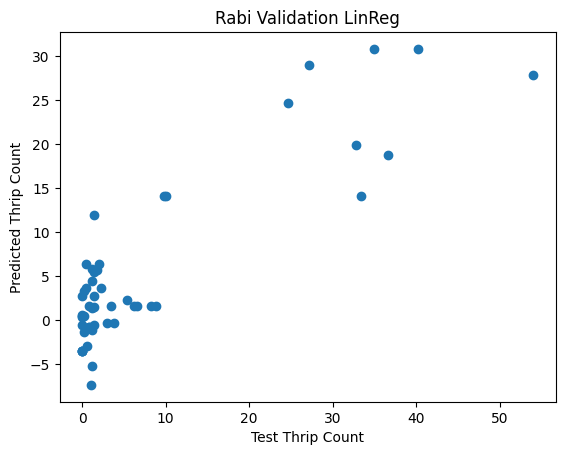

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
dataset = rabi_data.get_dataset(rabi_data.thrips_data.filter(regex='^R').columns)
X = dataset.drop('thrip_count', axis = 1)
features = X.columns
y = dataset['thrip_count']

X = scaler.fit_transform(X)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=100)
model = LinearRegression()
sfs = SequentialFeatureSelector(model, n_features_to_select='auto', direction='forward')
sfs.fit(Xtrain, ytrain)
subset = [features[index] for index in sfs.get_support(indices=True)]
train = Xtrain[:, sfs.get_support(indices=True)]
model.fit(train, ytrain)
ypred = model.predict(Xtest[:, sfs.get_support(indices=True)])
print("Subset:", subset)
print("R2:", r2_score(ytest, ypred))
print("RMSE:", root_mean_squared_error(ytest, ypred))
plt.scatter(ytest, ypred)
plt.title('Rabi Validation LinReg')
plt.xlabel('Test Thrip Count')
plt.ylabel('Predicted Thrip Count')

## SVR

SVR Root Mean Squared Error: 17.290073968277714
SVR R2 Score: 0.4297437239036813


Text(0, 0.5, 'Predicted Thrip Count')

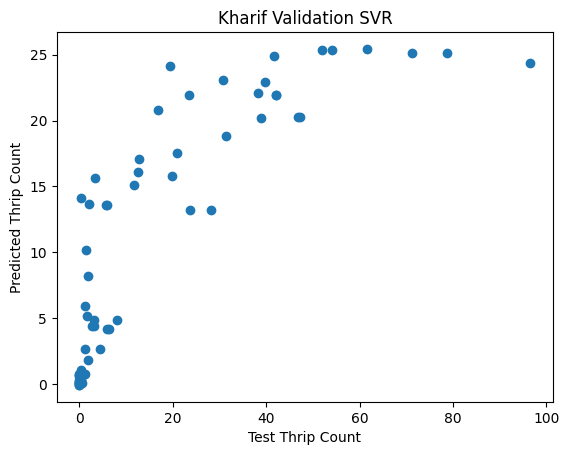

In [29]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
dataset = kharif_data.get_dataset(kharif_data.thrips_data.filter(regex='^R').columns)
X = dataset.drop('thrip_count', axis = 1)
features = X.columns
y = dataset['thrip_count']

X = scaler.fit_transform(X)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=100)
svr_model = SVR(kernel='rbf')
sfs = SequentialFeatureSelector(svr_model, n_features_to_select='auto', direction='forward')
sfs.fit(Xtrain, ytrain)
subset = [features[index] for index in sfs.get_support(indices=True)]
train = Xtrain[:, sfs.get_support(indices=True)]
svr_model.fit(train, ytrain)
y_pred_svr = svr_model.predict(Xtest[:, sfs.get_support(indices=True)])
mse_svr = root_mean_squared_error(ytest, y_pred_svr)
r2_svr = r2_score(ytest, y_pred_svr)

print(f"SVR Root Mean Squared Error: {mse_svr}")
print(f"SVR R2 Score: {r2_svr}")
plt.scatter(ytest, y_pred_svr)
plt.title('Kharif Validation SVR')
plt.xlabel('Test Thrip Count')
plt.ylabel('Predicted Thrip Count')

SVR Root Mean Squared Error: 8.426877385130009
SVR R2 Score: 0.5754951641585457


Text(0, 0.5, 'Predicted Thrip Count')

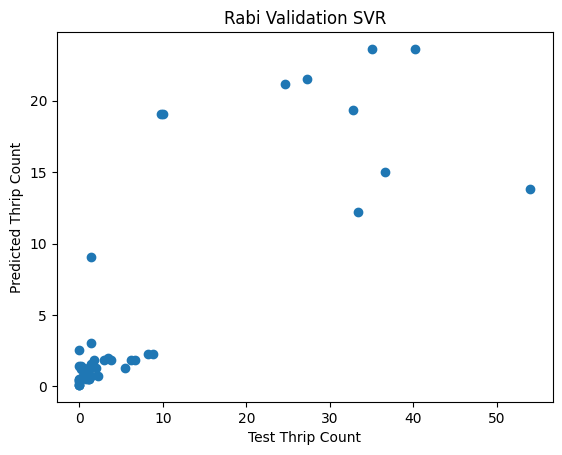

In [30]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
dataset = rabi_data.get_dataset(rabi_data.thrips_data.filter(regex='^R').columns)
X = dataset.drop('thrip_count', axis = 1)
features = X.columns
y = dataset['thrip_count']

X = scaler.fit_transform(X)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=100)
svr_model = SVR(kernel='rbf')
sfs = SequentialFeatureSelector(svr_model, n_features_to_select='auto', direction='forward')
sfs.fit(Xtrain, ytrain)
subset = [features[index] for index in sfs.get_support(indices=True)]
train = Xtrain[:, sfs.get_support(indices=True)]
svr_model.fit(train, ytrain)
y_pred_svr = svr_model.predict(Xtest[:, sfs.get_support(indices=True)])
mse_svr = root_mean_squared_error(ytest, y_pred_svr)
r2_svr = r2_score(ytest, y_pred_svr)

print(f"SVR Root Mean Squared Error: {mse_svr}")
print(f"SVR R2 Score: {r2_svr}")
plt.scatter(ytest, y_pred_svr)
plt.title('Rabi Validation SVR')
plt.xlabel('Test Thrip Count')
plt.ylabel('Predicted Thrip Count')

## RFR

RFR Root Mean Squared Error: 5.853531848379845
RFR R2 Score: 0.9346399549978879
Train score R2:  0.9842148190463552
Train score RMSE:  2.4657609940000884


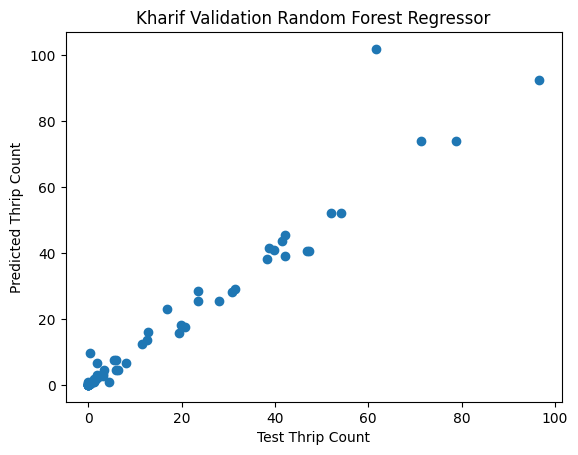

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
dataset = kharif_data.get_dataset(kharif_data.thrips_data.filter(regex='^R').columns)
X = dataset.drop('thrip_count', axis = 1)
features = X.columns
y = dataset['thrip_count']

# X = scaler.fit_transform(X)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=100)

# Create and train the Random Forest Regressor model
rfr_model = RandomForestRegressor(n_estimators=100, random_state=42)  # You can tune n_estimators and other hyperparameters

rfr_model.fit(Xtrain, ytrain)

# # Predict on test data
y_pred_rfr = rfr_model.predict(Xtest)

# Evaluate the Random Forest model
mse_rfr = root_mean_squared_error(ytest, y_pred_rfr)
r2_rfr = r2_score(ytest, y_pred_rfr)

print(f"RFR Root Mean Squared Error: {mse_rfr}")
print(f"RFR R2 Score: {r2_rfr}")
plt.scatter(ytest, y_pred_rfr)
plt.title('Kharif Validation Random Forest Regressor')
plt.xlabel('Test Thrip Count')
plt.ylabel('Predicted Thrip Count')

print("Train score R2: ", r2_score(ytrain, rfr_model.predict(Xtrain)))
print("Train score RMSE: ", root_mean_squared_error(ytrain, rfr_model.predict(Xtrain)))

Loaded Rabi 2024 dataset
RFR Root Mean Squared Error: 5.6997849368572995
RFR R2 Score: 0.8057923956980112


Text(0, 0.5, 'Predicted Thrip Count')

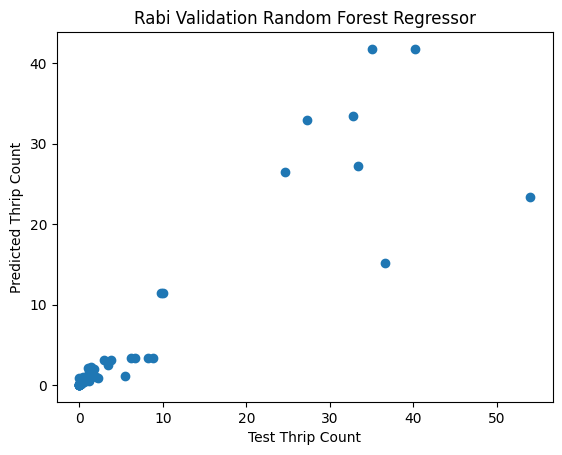

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
dataset = rabi_data.get_dataset(rabi_data.thrips_data.filter(regex='^R').columns)
print("Loaded Rabi 2024 dataset")
X = dataset.drop('thrip_count', axis = 1)
features = X.columns
y = dataset['thrip_count']

# X = scaler.fit_transform(X)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=100)

# Create and train the Random Forest Regressor model
rfr_model = RandomForestRegressor(n_estimators=100, random_state=42)  # You can tune n_estimators and other hyperparameters

rfr_model.fit(Xtrain, ytrain)

# Predict on test data
y_pred_rfr = rfr_model.predict(Xtest)

# Evaluate the Random Forest model
mse_rfr = root_mean_squared_error(ytest, y_pred_rfr)
r2_rfr = r2_score(ytest, y_pred_rfr)

print(f"RFR Root Mean Squared Error: {mse_rfr}")
print(f"RFR R2 Score: {r2_rfr}")
plt.scatter(ytest, y_pred_rfr)
plt.title('Rabi Validation Random Forest Regressor')
plt.xlabel('Test Thrip Count')
plt.ylabel('Predicted Thrip Count')

## GBR

GBR Root Mean Squared Error: 5.819490553807225
GBR R2 Score: 0.9353979489805176


Text(0, 0.5, 'Predicted Thrip Count')

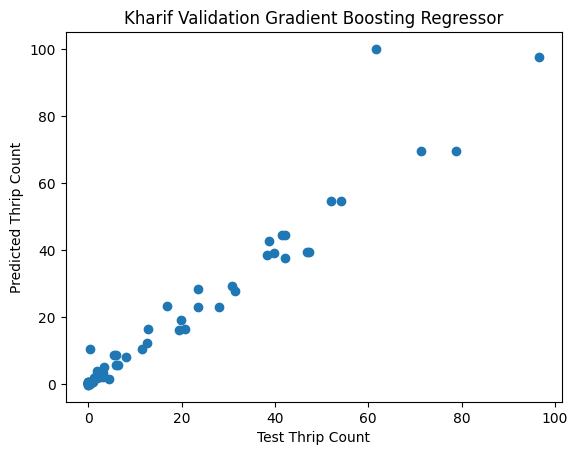

In [33]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
dataset = kharif_data.get_dataset(kharif_data.thrips_data.filter(regex='^R').columns)
X = dataset.drop('thrip_count', axis = 1)
features = X.columns
y = dataset['thrip_count']

X = scaler.fit_transform(X)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=100)

# Create and train the Random Forest Regressor model
gbr_model = GradientBoostingRegressor(random_state=42) 

gbr_model.fit(Xtrain, ytrain)

# Predict on test data
y_pred_gbr = gbr_model.predict(Xtest)

# Evaluate the Random Forest model
mse_gbr = root_mean_squared_error(ytest, y_pred_gbr)
r2_gbr = r2_score(ytest, y_pred_gbr)

print(f"GBR Root Mean Squared Error: {mse_gbr}")
print(f"GBR R2 Score: {r2_gbr}")
plt.scatter(ytest, y_pred_gbr)
plt.title('Kharif Validation Gradient Boosting Regressor')
plt.xlabel('Test Thrip Count')
plt.ylabel('Predicted Thrip Count')

Loaded Rabi 2024 dataset
GBR Root Mean Squared Error: 5.402124203589411
GBR R2 Score: 0.8255470078903704


Text(0, 0.5, 'Predicted Thrip Count')

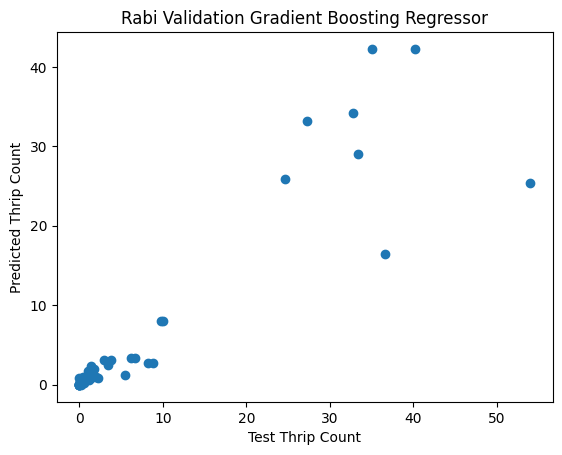

In [6]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
dataset = rabi_data.get_dataset(rabi_data.thrips_data.filter(regex='^R').columns)
print("Loaded Rabi 2024 dataset")
X = dataset.drop('thrip_count', axis = 1)
features = X.columns
y = dataset['thrip_count']

X = scaler.fit_transform(X)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=100)

# Create and train the Random Forest Regressor model
gbr_model = GradientBoostingRegressor(random_state=42) 

gbr_model.fit(Xtrain, ytrain)

# Predict on test data
y_pred_gbr = gbr_model.predict(Xtest)

# Evaluate the Random Forest model
mse_gbr = root_mean_squared_error(ytest, y_pred_gbr)
r2_gbr = r2_score(ytest, y_pred_gbr)

print(f"GBR Root Mean Squared Error: {mse_gbr}")
print(f"GBR R2 Score: {r2_gbr}")
plt.scatter(ytest, y_pred_gbr)
plt.title('Rabi Validation Gradient Boosting Regressor')
plt.xlabel('Test Thrip Count')
plt.ylabel('Predicted Thrip Count')

## R2 and RMSE All Models

In [35]:
# Model training and validation for Rabi 2024 data.
from sklearn.model_selection import KFold
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
load_data = DataLoader(thrips='C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Thrips Data\Clean_Data\Rabi_Data.csv', format='%m/%d/%Y')
dataset = load_data.get_dataset(load_data.thrips_data.filter(regex='^R').columns, start = False, cache=False)
scaler = StandardScaler()
X = dataset.drop('thrip_count', axis = 1)
X = scaler.fit_transform(X)
y = dataset['thrip_count']
models = [LinearRegression(), SVR(kernel='rbf'), RandomForestRegressor(n_estimators=100, random_state=42), GradientBoostingRegressor(random_state=101)]
for model in models:
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # To store the results for each fold
    fold_results = {
        'r2_score': [], 'rmse': []
    }

    # Perform K-Fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Fit the model on the training data
        model.fit(X_train, y_train)
        
        # Evaluate on the test data
        r2_score = model.score(X_test, y_test)  # R^2 score by default
        y_pred = model.predict(X_test)
        rmse = root_mean_squared_error(y_test, y_pred)
        fold_results['r2_score'].append(r2_score)
        fold_results['rmse'].append(rmse)

    # Print results
    print(model)
    print("Fold results: ", fold_results)
    print("Average score: ", np.mean(fold_results['r2_score']))


LinearRegression()
Fold results:  {'r2_score': [0.7211984253073058, 0.6760016241591551, 0.707277464863888, 0.7716787571721111, 0.6286151569141739], 'rmse': [6.224852133577696, 6.946592812565193, 8.203916460059338, 6.859081198703106, 6.536187638821546]}
Average score:  0.7009542856833268
SVR()
Fold results:  {'r2_score': [0.6302314628170299, 0.5839284728828062, 0.49195057197783143, 0.39409206420267184, 0.5978866548932613], 'rmse': [7.168799037235646, 7.87198802027399, 10.808019855124485, 11.173676783825323, 6.801217550242145]}
Average score:  0.5396178453547201
RandomForestRegressor(random_state=42)
Fold results:  {'r2_score': [0.9358181362007465, 0.8994397858401981, 0.8581174252811605, 0.9169422954732995, 0.8368059602471078], 'rmse': [2.986672414040823, 3.8700227751513183, 5.711598632401734, 4.136973570650802, 4.332759370638628]}
Average score:  0.8894247206085024
GradientBoostingRegressor()
Fold results:  {'r2_score': [0.9424060729656139, 0.8851599438904658, 0.8401066828905003, 0.9266

In [44]:
# Model training and validation for Kharif 2023 data.
from sklearn.model_selection import KFold
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
load_data = DataLoader(thrips='C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Thrips Data\Clean_Data\Kharif_Data.csv')
dataset = load_data.get_dataset(load_data.thrips_data.filter(regex='^R').columns, start = False, cache=False)
scaler = StandardScaler()
X = dataset.drop('thrip_count', axis = 1)
X = scaler.fit_transform(X)
y = dataset['thrip_count']
models = [LinearRegression(), SVR(kernel='rbf'), RandomForestRegressor(n_estimators=100, random_state=42), GradientBoostingRegressor()]
for model in models:
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # To store the results for each fold
    fold_results = {
        'r2_score': [], 'rmse': []
    }

    # Perform K-Fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Fit the model on the training data
        model.fit(X_train, y_train)
        
        # Evaluate on the test data
        r2_score = model.score(X_test, y_test)  # R^2 score by default
        y_pred = model.predict(X_test)
        rmse = root_mean_squared_error(y_test, y_pred)
        fold_results['r2_score'].append(r2_score)
        fold_results['rmse'].append(rmse)

    # Print results
    print(model)
    print("Fold results: ", fold_results)
    print("Average score: ", np.mean(fold_results['r2_score']))


LinearRegression()
Fold results:  {'r2_score': [0.5326842412197863, 0.7053294454183878, 0.68595956787488, 0.7084537227119745, 0.36097356632487065], 'rmse': [12.444088429809865, 11.051154926401065, 12.60482775884377, 13.076081788390622, 11.976795225007516]}
Average score:  0.5986801087099798
SVR()
Fold results:  {'r2_score': [0.4391464538426746, 0.3625573796719178, 0.3423695157968921, 0.25610468366085937, 0.44874197431886664], 'rmse': [13.632722999108468, 16.253984674793948, 18.240431197374935, 20.88717908409949, 11.123940960237922]}
Average score:  0.3697840014582421
RandomForestRegressor(random_state=42)
Fold results:  {'r2_score': [0.8924986139538295, 0.9097357174183431, 0.964022451746113, 0.9531950034777767, 0.9444829155144039], 'rmse': [5.96849600142718, 6.116419503498253, 4.266383730968231, 5.2392604323253895, 3.5301612050478015]}
Average score:  0.9327869404220932
GradientBoostingRegressor()
Fold results:  {'r2_score': [0.9072516179889898, 0.9163984630486226, 0.960029477041829, 0

# Regularization

## RFR

In [83]:
# Regularize RandomForestRegressor using grid search CV
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
# from sklearn.linear_model import LinearRegression
# from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
load_data = DataLoader(thrips='C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Thrips Data\Clean_Data\Rabi_Data.csv', format='%m/%d/%Y')
dataset = load_data.get_dataset(load_data.thrips_data.filter(regex='^R').columns, start = False, cache=False)
scaler = StandardScaler()
X = dataset.drop('thrip_count', axis = 1)
X = scaler.fit_transform(X)
y = dataset['thrip_count']

model = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': list(range(10, 110, 10)),
    'max_depth': [5, 10, 15], 
    'min_samples_split': [2, 4, 8, 10],
    'warm_start': [True, False],
    'min_samples_leaf': [1, 2, 4, 8, 16], 
    'criterion': ['squared_error', 'friedman_mse']
}
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

grid_search = GridSearchCV(model, param_grid, scoring='r2', cv = kfold, n_jobs=-1, verbose=2)

grid_search.fit(X, y)

Fitting 10 folds for each of 2400 candidates, totalling 24000 fits


c:\Users\manas\anaconda3\envs\env\lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=KFold(n_splits=10, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'friedman_mse'],
                         'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 4, 8, 16],
                         'min_samples_split': [2, 4, 8, 10],
                         'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90,
                                          100],
                         'warm_start': [True, False]},
             scoring='r2', verbose=2)

In [90]:
print("Best Parameters:", grid_search.best_params_)
print("Best Score (R2 Score):", grid_search.best_score_)
best_rf = grid_search.best_estimator_
print('RMSE: ', root_mean_squared_error(y, best_rf.predict(X)))

Best Parameters: {'criterion': 'squared_error', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 80, 'warm_start': True}
Best Score (R2 Score): 0.8429568852514592
RMSE:  3.2855398347006934


In [ ]:
# To save model
import pickle
with open('Models/random_forest_model_regularized.pkl', 'wb') as file:
    pickle.dump(best_rf, file)

## GBR

In [79]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.datasets import make_regression
from sklearn.metrics import root_mean_squared_error

dataset = load_data.get_dataset(load_data.thrips_data.filter(regex='^R').columns, start = False, cache=False)
scaler = StandardScaler()
X = dataset.drop('thrip_count', axis = 1)
X = scaler.fit_transform(X)
y = dataset['thrip_count']

gbr = GradientBoostingRegressor(random_state=101)

param_grid = {
    'n_estimators': [50, 100, 150],  # Lower number of boosting stages
    'learning_rate': [0.01, 0.05, 0.1],  # Smaller learning rates for regularization
    'max_depth': [2, 3, 4],  # Shallow trees to prevent overfitting
    'min_samples_split': [2, 5, 10],  # Larger values reduce complexity
    'min_samples_leaf': [1, 2, 4],  # Larger leaf size reduces variance
    'subsample': [0.7, 0.8, 0.9],  # Fraction of samples to prevent overfitting
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid, 
                           cv=kfold, scoring='r2', 
                           n_jobs=-1, verbose=2)

# Fit the grid search
grid_search.fit(X, y)

# Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Score (R2 Score):", grid_search.best_score_)

# Use the best model for predictions
best_gbr = grid_search.best_estimator_
y_pred = best_gbr.predict(X)

# Evaluate the model
print("Root Mean Squared Error:", root_mean_squared_error(y, y_pred))


Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50, 'subsample': 0.9}
Best Score (R2 Score): 0.8887008543382722
Root Mean Squared Error: 3.285823546863083


In [80]:
import pickle
with open('Models/gbr_regularized.pkl', 'wb') as file:
    pickle.dump(best_gbr, file)

# Handling IMD Data

In [13]:
def convert_IMD_Data(path='C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Weather data\IMD_data.xlsx'):
    weather_22 = pd.read_excel(path)
    weather_22['TIME(UTC)'] = weather_22['TIME(UTC)'].apply(lambda x: datetime.timedelta(hours=x.hour+5, minutes=x.minute+30, seconds=x.second))
    weather_22['Date'] = weather_22['DATE'] + pd.to_timedelta(weather_22['TIME(UTC)'])
    weather_22 = weather_22[['Date', 'RAIN_HOURLY(mm)', 'TEMP(C)', 'RH(%)']]
    weather_22.rename(columns={'RAIN_HOURLY(mm)': 'Rain(mm)', 'TEMP(C)': 'Temp'}, inplace=True)
    subset = weather_22[(weather_22['Date'].dt.date>datetime.date(2022, 12, 5)) & (weather_22['Date'].dt.date<datetime.date(2023, 1, 1))].copy(deep = True)
    subset.fillna(0, inplace=True)
    weather_23 = pd.read_csv('C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Weather data\Integrated_Data_23_24.csv')
    weather_23.drop('Unnamed: 0', axis = 1, inplace=True)
    weather_23['Date'] = pd.to_datetime(weather_23['Date'], format='%Y-%m-%d %H:%M:%S')
    rabi_weather = pd.concat([subset, weather_23], axis = 0)
    rabi_weather = rabi_weather[rabi_weather['Date'].dt.date<datetime.date(2023, 3, 20)]
    rabi_weather.reset_index(drop = True, inplace=True)
    return rabi_weather
def convert_thrips_data(path = 'C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Thrips Data\Thrips_Obs200523 (Rabi 23).csv'):
    rabi_23 = pd.read_csv(path, skiprows=2, skipfooter=1)
    rabi_23.rename(columns={'Unnamed: 0': 'Date', 'Unnamed: 3': 'R1P1', 'Unnamed: 6': 'R2P1'}, inplace=True)
    rabi_23.drop(['IPM', 'Calendar Spray', 'IPM.1', 'Calendar Spray.1'], axis=1, inplace=True)
    return rabi_23

# Testing  on Rabi 2023 Data

In [14]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
dop = {'1': '21-12-2022'}
load_data = DataLoader(thrips='C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Thrips Data\Clean_Data\Rabi_Data.csv', format='%m/%d/%Y', dop=RABI_DOP)
dataset = load_data.get_dataset(load_data.thrips_data.filter(regex='^R').columns, start = False, cache=False)
scaler = StandardScaler()
X_train = dataset.drop('thrip_count', axis = 1)
X_train = scaler.fit_transform(X_train)
y_train = dataset['thrip_count']
rabi_weather = pd.read_csv('C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Weather Data\Rabi_2023_Weather.csv')
rabi_weather['Date'] = pd.to_datetime(rabi_weather['Date'], format="%Y-%m-%d %H:%M:%S")
rabi_23 = pd.read_csv('C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Thrips Data\Clean_Data\Rabi_2023.csv')
test_data = DataLoader(dop=dop, weather=rabi_weather, thrips=rabi_23, format='%Y-%m-%d')
test_dataset = test_data.get_dataset(rabi_23.filter(regex='^R').columns, cache=False)
X_test = test_dataset.drop('thrip_count', axis = 1)
X_test = scaler.transform(X_test)
y_test = test_dataset['thrip_count']
models = [LinearRegression(), SVR(kernel='rbf'), RandomForestRegressor(n_estimators=100, random_state=42), GradientBoostingRegressor()]
# models = [best_gbr, best_rf]
errors = []
r2_scores = []
for model in models:
    model.fit(X_train, y_train)
    rmse = root_mean_squared_error(y_test, model.predict(X_test))
    r2_score = model.score(X_test, y_test)
    errors.append(rmse)
    r2_scores.append(r2_score)
    print(model, ': ', '\nRMSE: ', rmse, '\tR2_Score: ', r2_score, sep='')


LinearRegression(): 
RMSE: 27.59529816340071	R2_Score: -0.8136236319807433
SVR(): 
RMSE: 22.036571003477217	R2_Score: -0.1565516127294475
RandomForestRegressor(random_state=42): 
RMSE: 20.441209941052758	R2_Score: 0.004846255196396365
GradientBoostingRegressor(): 
RMSE: 19.199455119529688	R2_Score: 0.12208030597347186


Text(0, 0.5, 'Rabi 2023 thrips')

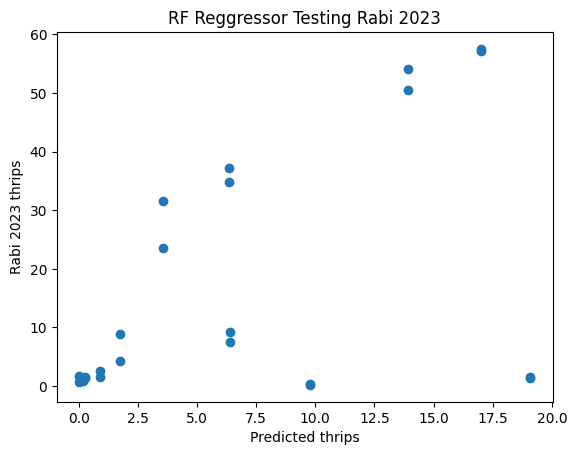

In [47]:
y_pred = models[-2].predict(X_test)
plt.scatter(y_pred, y_test)
plt.title('RF Reggressor Testing Rabi 2023')
plt.xlabel('Predicted thrips')
plt.ylabel('Rabi 2023 thrips')

# KS Statistic

In [17]:
dop = {'1': '21-12-2022'}
rabi_weather = convert_IMD_Data()
rabi_23 = convert_thrips_data()
test_data = DataLoader(dop=dop, weather=rabi_weather, thrips=rabi_23, format='%d-%m-%Y')
test_dataset = test_data.get_dataset(rabi_23.filter(regex='^R').columns, cache=False)
load_data = DataLoader(thrips='C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Thrips Data\Clean_Data\Rabi_Data.csv', format='%m/%d/%Y', dop=RABI_DOP)
dataset = load_data.get_dataset(load_data.thrips_data.filter(regex='^R').columns, start = False, cache=False)

C:\Users\manas\AppData\Local\Temp\ipykernel_38540\2083638904.py:17: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  rabi_23 = pd.read_csv(path, skiprows=2, skipfooter=1)


In [19]:
from scipy import stats

for col in dataset.columns:
    data_1 = dataset[col].to_numpy()
    data_2 = test_dataset[col].to_numpy()
    p_values = []
    statistics = []
    for i in range(1000):

        data_1_sub = np.random.choice(data_1, size = len(data_2), replace=False)
        statistic, p_value = stats.ks_2samp(data_1_sub, data_2)
        p_values.append(p_value)
        statistics.append(statistic)
    
    print("Variable:", col)
    if np.mean(p_values)<0.05:
        print("Distributions from 2023 and 2024 are different at 95% confidence.")
    else:
        print("Distributions are similar at 95% confidence.")

Variable: rain0
Distributions from 2023 and 2024 are different at 95% confidence.
Variable: rain1
Distributions from 2023 and 2024 are different at 95% confidence.
Variable: rain2
Distributions from 2023 and 2024 are different at 95% confidence.
Variable: rh10
Distributions are similar at 95% confidence.
Variable: rh11
Distributions are similar at 95% confidence.
Variable: rh12
Distributions are similar at 95% confidence.
Variable: rh20
Distributions are similar at 95% confidence.
Variable: rh21
Distributions are similar at 95% confidence.
Variable: rh22
Distributions are similar at 95% confidence.
Variable: tmax0
Distributions are similar at 95% confidence.
Variable: tmax1
Distributions are similar at 95% confidence.
Variable: tmax2
Distributions are similar at 95% confidence.
Variable: tmean0
Distributions are similar at 95% confidence.
Variable: tmean1
Distributions are similar at 95% confidence.
Variable: tmean2
Distributions are similar at 95% confidence.
Variable: tmin0
Distribut

- Given that the distributions are similar, we cannot rule out the possibility that the model is over training. 

# Sample Testing

In [49]:
import pickle
scaler = pickle.load(open('scaler.pkl', 'rb'))
sample_data = DataLoader(dop = {'1': '05-08-2024'}, weather=convert_SAMBHAV_Data(path = "C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Weather data\August2024_September2024_Data.xlsx"))
dates = pd.Series(generate_dates('2024-08-20', '2024-09-21', 7))
sample_test = sample_data.get_lag_weather(dates)
sample_test['Age'] = sample_test['Date'].apply(lambda x: (pd.Timestamp(x) - sample_data.dop['1']).days)
sample_test.drop(['Date'], axis = 1, inplace=True)
Xtest = scaler.transform(sample_test)

c:\Users\manas\anaconda3\envs\env\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [51]:
Xtest.shape

(5, 19)

In [53]:
ypred = rfr_model.predict(Xtest)

In [57]:
Xtest.shape

(5, 19)

In [59]:
ypred

array([81.2394    , 81.1938    , 81.61521667, 79.99655   , 84.40393333])

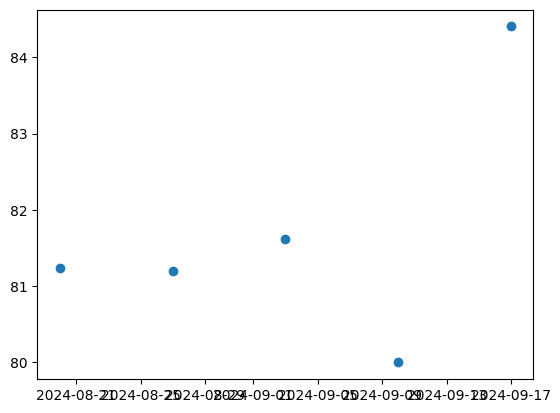

In [58]:
plt.scatter(dates, ypred)

# SHAP Explainable

In [32]:
# Try SHAP explainations of features

import shap
shap.initjs()

explainer = shap.TreeExplainer(rfr_model)
shap_values = explainer.shap_values(X)

In [33]:
features = list(kharif_dataset.columns)
features.pop(-1)
print(features)

['rain0', 'rain1', 'rain2', 'rh10', 'rh11', 'rh12', 'rh20', 'rh21', 'rh22', 'tmax0', 'tmax1', 'tmax2', 'tmean0', 'tmean1', 'tmean2', 'tmin0', 'tmin1', 'tmin2', 'Age']


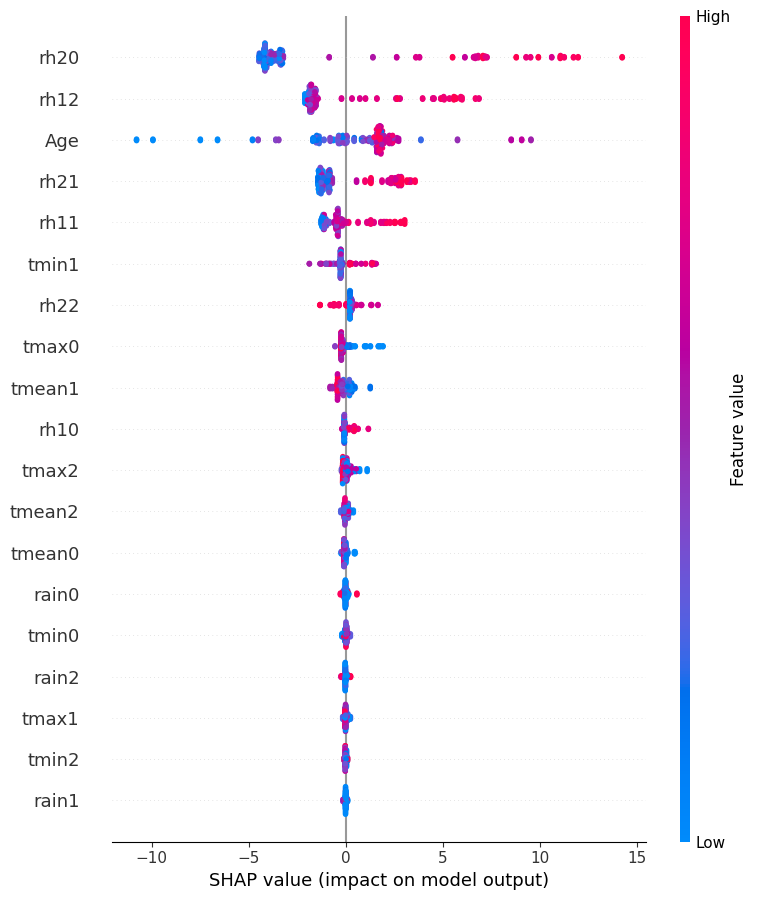

In [34]:
shap.summary_plot(shap_values, X, feature_names=features)

In [78]:
shap.plots.force(explainer.expected_value, shap_values, feature_names=features)

In [28]:
Xtrain

,rain0,rain1,rain2,rh10,rh11,rh12,rh20,rh21,rh22,tmax0,tmax1,tmax2,tmean0,tmean1,tmean2,tmin0,tmin1,tmin2,Age
118,1812.0,2226.7,1005.0,86.542157,89.981000,89.249515,85.582353,87.855340,85.831068,28.4,28.3,30.3,24.756680,24.573670,25.115510,22.5,22.5,23.1,10
287,0.0,430.5,11.0,78.310000,73.403846,45.127451,43.440000,46.480000,22.784314,34.6,35.4,36.8,24.636081,26.692732,27.914919,15.4,17.2,20.6,52
59,2240.0,344.5,1397.0,85.009615,85.818182,89.864078,80.722772,74.680000,87.030928,32.3,35.3,29.9,25.346102,26.147218,24.792982,21.4,20.2,21.7,17
69,0.0,138.5,4990.0,60.485437,65.666667,76.495050,28.851485,39.339806,61.088235,36.8,37.3,33.7,27.706024,26.806158,25.633109,20.6,19.3,22.3,52
160,511.5,2240.0,344.5,79.403846,85.009615,85.818182,72.550000,80.722772,74.680000,30.9,32.3,35.3,25.192432,25.346102,26.147218,21.1,21.4,20.2,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,2704.0,5274.0,1172.0,67.196078,74.970588,73.461538,46.708738,72.414141,67.390000,35.5,33.2,32.3,26.054339,25.345405,25.237047,19.3,22.3,21.1,41
53,138.5,4990.0,3226.0,65.666667,76.495050,71.893204,39.339806,61.088235,68.455446,37.3,33.7,32.3,26.806158,25.633109,25.452667,19.3,22.3,22.5,62
79,6255.0,1515.5,2158.5,77.284314,71.126214,84.673077,73.480000,66.980198,79.346535,33.7,32.3,30.9,25.263968,25.215508,25.227544,22.3,21.1,21.1,18
280,138.5,4990.0,3226.0,65.666667,76.495050,71.893204,39.339806,61.088235,68.455446,37.3,33.7,32.3,26.806158,25.633109,25.452667,19.3,22.3,22.5,28


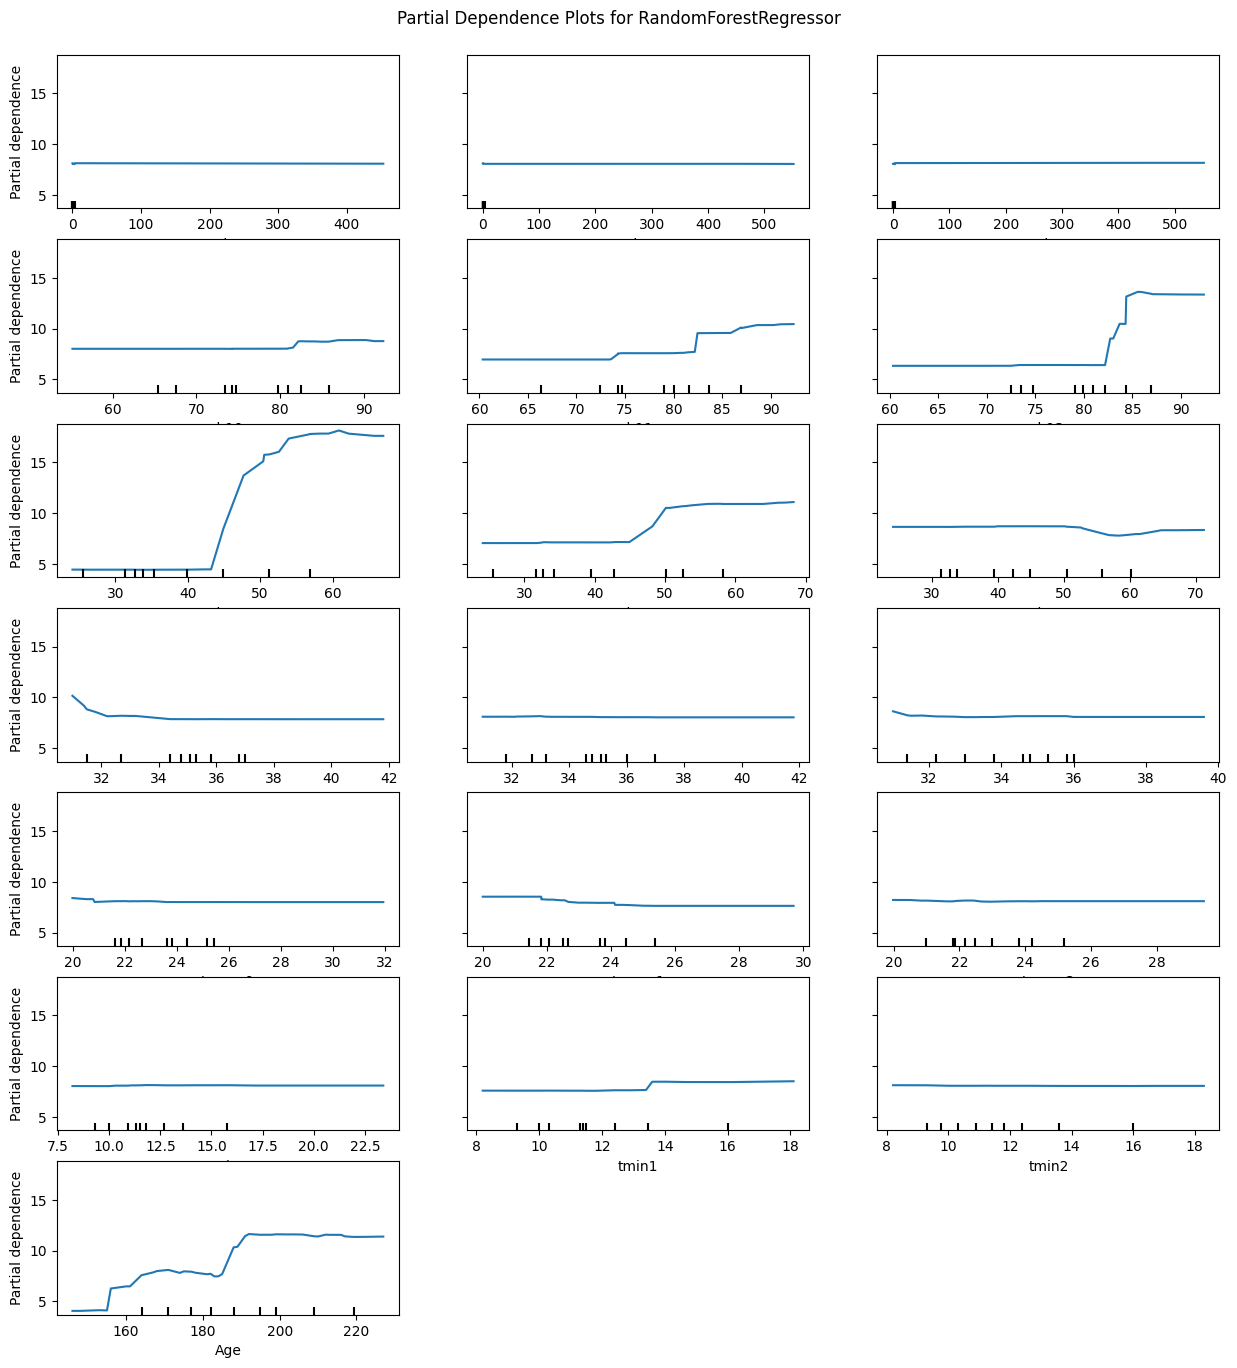

In [31]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# List of features for which we want to plot the PDP
features = rabi_dataset.drop(['thrip_count'], axis = 1).columns  # replace with features of interest

# Plotting Partial Dependence Plots
fig, ax = plt.subplots(figsize=(15, 15))
PartialDependenceDisplay.from_estimator(rfr_model, Xtrain, features, ax=ax)

# Adding labels and title
plt.suptitle('Partial Dependence Plots for RandomForestRegressor')
plt.subplots_adjust(top=0.95)  # Adjusts the plot to make room for the title
plt.show()


In [10]:
print(features)

Index(['rain0', 'rain1', 'rain2', 'rh10', 'rh11', 'rh12', 'rh20', 'rh21',
       'rh22', 'tmax0', 'tmax1', 'tmax2', 'tmean0', 'tmean1', 'tmean2',
       'tmin0', 'tmin1', 'tmin2', 'Age'],
      dtype='object')


# Data Analysis

In [20]:
kharif_distribution = kharif_data.get_thrips_distribution(season = 'Kharif',  save_plot=True)
# rabi_distribution = rabi_data.get_thrips_distribution(season = 'Rabi',  save_plot=False)

In [21]:
kharif_distribution

,rain0,rain1,rain2,rh10,rh11,rh12,rh20,rh21,rh22,tmax0,tmax1,tmax2,tmean0,tmean1,tmean2,tmin0,tmin1,tmin2,Age,thrip_count
0,16.0-17.5,4.5-7.0,8.5-14.0,87.5-92.36,84.15-89.98,87.67-89.98,77.79-87.49,82.52-87.86,72.41-80.98,28.3-29.4,28.3-30.9,31.5-32.3,24.07-24.85,25.01-25.29,25.8-26.15,22.0-23.1,22.0-23.1,22.0-23.2,15,1.8
1,0.0-1.5,1.5-4.0,2.5-7.0,87.5-92.36,84.15-89.98,87.67-89.98,77.79-87.49,82.52-87.86,72.41-80.98,28.3-29.4,28.3-30.9,28.3-30.9,24.07-24.85,24.19-24.85,25.8-26.15,22.0-23.1,22.0-23.1,22.0-23.2,20,5.6
2,0.0-1.5,1.5-4.0,0.0-1.5,81.59-87.17,84.15-89.98,87.67-89.98,77.79-87.49,82.52-87.86,82.52-87.86,28.3-29.4,28.3-30.9,28.3-30.9,24.07-24.85,24.19-24.85,25.01-25.63,22.0-23.1,22.0-23.1,22.0-23.2,23,7.5
3,0.0-1.5,0.0-0.5,2.5-7.0,81.59-87.17,84.15-89.98,87.67-89.98,77.79-87.49,82.52-87.86,82.52-87.86,28.3-29.4,28.3-30.9,28.3-30.9,25.01-25.55,24.19-24.85,24.31-24.85,22.0-23.1,22.0-23.1,22.0-23.2,27,18.3
4,0.0-1.5,1.5-4.0,2.5-7.0,81.59-87.17,84.15-89.98,87.67-89.98,77.79-87.49,82.52-87.86,82.52-87.86,28.3-29.4,28.3-30.9,28.3-30.9,25.01-25.55,24.19-24.85,24.31-24.85,22.0-23.1,22.0-23.1,22.0-23.2,30,15.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,0.0-1.5,0.0-0.5,0.0-1.5,81.59-87.17,76.5-81.59,71.89-80.07,55.73-63.64,55.73-67.75,34.83-49.4,32.3-33.8,33.2-34.3,33.2-34.3,24.07-24.85,25.35-25.63,25.01-25.63,15.2-16.4,16.4-17.2,15.2-17.4,70,1.2
293,0.0-1.5,0.0-0.5,0.0-1.5,81.59-87.17,84.15-89.98,71.89-80.07,55.73-63.64,55.73-67.75,56.48-70.41,32.3-33.8,33.2-34.3,33.2-34.3,24.07-24.85,25.01-25.29,25.01-25.63,15.2-16.4,15.2-16.0,15.2-17.4,73,4.9
294,0.0-1.5,13.0-18.0,8.5-14.0,87.5-92.36,84.15-89.98,82.28-87.17,65.52-74.68,55.73-67.75,56.48-70.41,32.3-33.8,33.2-34.3,33.2-34.3,24.07-24.85,24.19-24.85,25.01-25.63,15.2-16.4,15.2-16.0,15.2-17.4,78,1.2
295,0.0-1.5,0.0-0.5,0.0-1.5,87.5-92.36,84.15-89.98,82.28-87.17,65.52-74.68,55.73-67.75,56.48-70.41,32.3-33.8,33.2-34.3,33.2-34.3,24.07-24.85,24.19-24.85,25.01-25.63,16.5-18.1,15.2-16.0,15.2-17.4,80,4.9


In [ ]:
# Make heatmaps for pairs of weather parameters. 

# Training Final Models

In [9]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
dataset = rabi_data.get_dataset(rabi_data.thrips_data.filter(regex='^R').columns)
X = dataset.drop('thrip_count', axis = 1)
features = X.columns
y = dataset['thrip_count']
X = scaler.fit_transform(X)


gbr = GradientBoostingRegressor(random_state=101)
rfr = RandomForestRegressor(random_state=101)
gbr.fit(X, y)
print("GBR trained")
rfr.fit(X, y)
print("RFR Trained")

r2_gbr = r2_score(y, gbr.predict(X))
r2_rfr = r2_score(y, rfr.predict(X))

print("R2 Score GBR:", r2_gbr)
print("R2 Score RFR:", r2_rfr)



GBR trained
RFR Trained
R2 Score GBR: 0.9370200448638905
R2 Score RFR: 0.9359997901602178


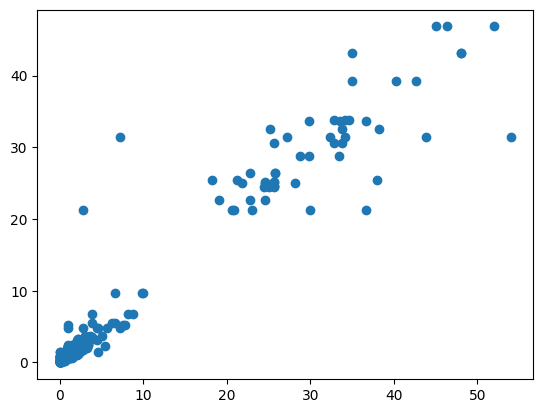

In [10]:
import matplotlib.pyplot as plt

plt.scatter(y, rfr.predict(X))

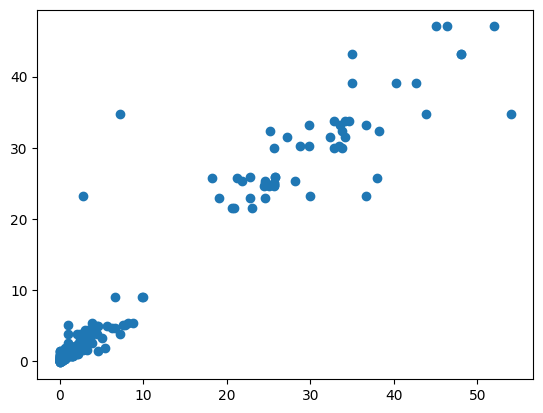

In [11]:
plt.scatter(y, gbr.predict(X))

In [12]:
import os
import pickle
# if not os.path.exists('Deliver/Models/Rabi'):
#     os.mkdir('Deliver/Models/Rabi')

# with open('Deliver/Models/Rabi/gbr_model.pkl', 'wb') as file:
#     pickle.dump(gbr, file)

# with open('Deliver/Models/Rabi/rfr_model.pkl', 'wb') as file:
#     pickle.dump(rfr, file)

# with open('Deliver/Models/Rabi/scaler.pkl', 'wb') as file:
#     pickle.dump(scaler, file)